## Clustering alogrithms for shape-based pattern identification

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Plots

In [2]:
def plot_cluster(ds, k_estimator, data_name, algo="k-shape"):

    time = ds.time.values
    _, count = np.unique(ds.cluster.values, return_counts=True)
    k = k_estimator.n_clusters

    fig, ax = plt.subplots(1, k, figsize=(3*k, 2.5), sharey=True)
    ax = np.atleast_1d(ax)

    for x, i in enumerate(range(k)):
        ax[x].plot(time, k_estimator.cluster_centers_[i], lw=2, c="k")
        ax[x].set(title=f"Cluster {i} ({count[i]})",xlabel="time (hpf)")

    plt.suptitle(f"Expression clusters by {algo} ({data_name})")
    plt.tight_layout()
    plt.savefig(f"figs/{algo}_cluster_{data_name}.png", dpi=300, transparent=True)
    plt.show()


def plot_heatmap(ds, X_z, data_name, algo="k-shape"):

    from matplotlib.colors import ListedColormap

    # cluster labels
    clusters = ds['cluster'].values
    # time axis (index of max expression per gene)
    time_idx = X_z.argmax(dim="time").values
    #time_idx = X_z.argmax(axis=1)
    
    # build structured sort: first cluster, then peak time
    sorted_genes = np.lexsort((time_idx, clusters))
    expr_plot = X_z.isel(ensembl_gene_id=sorted_genes)
    sorted_clusters = clusters[sorted_genes]

    # unique clusters in sorted order
    unique_clusters, start_idx = np.unique(sorted_clusters, return_index=True)
    end_idx = np.r_[start_idx[1:], len(sorted_clusters)]     # find end indices
    centers = (start_idx + end_idx) / 2     # compute vertical centers for labels

    cluster_cmap = ListedColormap(sns.color_palette("Set1", len(np.unique(clusters))))

    fig = plt.figure(figsize=(8,7))
    gs = fig.add_gridspec(1, 2, width_ratios=[0.015, 1], wspace=0.01)

    # Cluster bar (left)
    ax_bar = fig.add_subplot(gs[0])
    ax_bar.imshow(sorted_clusters[:, None], aspect='auto', cmap=cluster_cmap)
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])
    #ax_bar.set_ylabel("Genes (sorted by cluster)")

    # Add cluster numbers
    for c, y in zip(unique_clusters, centers):
        ax_bar.text( 0.05, y, str(c),
            ha='center', va='center',
            fontsize=12, fontweight='bold',
            color='black',
            transform=ax_bar.transData
        )

    # Heatmap
    ax = fig.add_subplot(gs[1])

    sns.heatmap(expr_plot.values,  # .T for white dataset --> changed dimensions in xarray (time, gid) instead of (gid, time)
        cmap='Spectral_r',
        yticklabels=False, xticklabels=expr_plot.time.values,
        ax=ax, cbar_kws={'label': 'expression', 'shrink': 0.5, 'pad': 0.02 }
    )
    
    ax.set_title(f'Gene expression pattern in $D. rerio$ by {algo} ({data_name})', fontsize=12)
    ax.set(xlabel='time (hpf)', ylabel='')
    #ax.tick_params("x", rotation=90)

    ax.vlines(3.5, *ax.get_ylim(), colors='k', linewidth=1, ls='--')

    # Find cluster boundaries
    boundaries = np.where(np.diff(sorted_clusters) != 0)[0]
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='k', linewidth=1.5)
    plt.tight_layout()
    plt.savefig(f"figs/{algo}_cluster_heatmap_{data_name}.png", dpi=300, transparent=True)
    plt.show()


## Fuzzy C-means 

In [15]:
# fuzzy c-means
from fcmeans import FCM
def fuzzy_cmeans(ds, data_name,k=5,):

    ds["tpm"] = np.log2(ds.tpm+1)
    X = ds["tpm"].transpose("ensembl_gene_id", "time")
    # Normalise
    #X_z = (X - X.mean("time")) / X.std("time")
    #X_z = (X- X.min("time")) /( X.max("time") - X.min("time"))

    X_z = (X - X.mean("time")) / abs(X- X.mean("time")).max("time")

    # fit the fuzzy-c-means
    fcm = FCM(n_clusters=k, random_state=1)
    fcm.fit(X_z.values)

    # outputs
    centers = fcm.centers
    u = fcm.u
    labels  = fcm.u.argmax(axis=1)

    # reindex clusters by peak time
    peak_times = np.argmax(centers, axis=1)   # peak time index per (old) cluster
    new_order = np.argsort(peak_times)        # old cluster ids, sorted by peak time
    rank = np.argsort(new_order)              # rank[old_id] = new_id

    centers_sorted = centers[new_order]       # centers reordered
    u_sorted = u[:, new_order]                # membership columns reordered
    labels_sorted = rank[labels]              # remap hard labels to new ids
    # create dataset
    ds = ds.assign_coords(clusters=("ensembl_gene_id", labels_sorted))

    cluster_assigned = xr.DataArray(
        u_sorted.argmax(axis=1), dims=("ensembl_gene_id"),
        coords={"ensembl_gene_id": ds.ensembl_gene_id},
    )
    ds["cluster"] = cluster_assigned

    membership = xr.DataArray(
        u_sorted ,dims=("ensembl_gene_id", "clusters"),
        coords={"ensembl_gene_id": ds.ensembl_gene_id,"clusters": np.arange(k),},)

    ds["membership"] = membership

    ds.to_netcdf(f"results/fuzzy_c-means_clustered_ds_{data_name}.nc")

    return ds, centers_sorted, X_z, fcm


def plot_fuzzy_cluster(ds, centers, data_name, algo="fuzzy_c-means"):

    time = ds.time.values
    _, count = np.unique(ds.cluster.values, return_counts=True) ## count of genes in that cluster
    k = len(ds.clusters)
    
    fig, ax = plt.subplots(1, k, figsize=(3*k, 2.5), sharey=True)
    ax = np.atleast_1d(ax)

    for x, i in enumerate(range(k)):
        ax[x].plot(time, centers[i], lw=2, c="k")
        ax[x].set(title=f"Cluster {i} ({count[i]})", xlabel="time (hpf)")

    plt.suptitle(f"Expression clusters by {algo} ({data_name})")
    plt.tight_layout()
    plt.savefig(f"figs/{algo}_cluster_{data_name}.png", dpi=300, transparent=True)
    plt.show()



In [18]:
data_name = "White et al."
#data_name = "Pauli et al."
#data_name= "BK"
#data_name = "JN"
data = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(source=data_name, drop=True)
# Keep only time steps where tpm has at least one non-NaN value
ds_clean = data.dropna(dim="time", how="all", subset=["tpm"])
ds_clean

# Keep only relevantly expressed genes
mask = ds_clean.tpm.max(dim="time", skipna=True) >= 5
ds_reduced = ds_clean.sel(ensembl_gene_id=mask)
ds_reduced

ds, centers, X_z, fcm= fuzzy_cmeans(ds_reduced, data_name, k=4,)
ds

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 20179, time: 18, clusters: 4)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 0.0 0.75 2.25 3.0 ... 48.0 72.0 96.0 120.0
  * clusters         (clusters) int32 0 1 2 3
Data variables:
    tpm              (time, ensembl_gene_id) float64 1.684 0.3531 ... 3.491
    cluster          (ensembl_gene_id) int64 0 3 1 0 1 0 2 2 ... 3 0 0 0 2 3 3 3
    membership       (ensembl_gene_id, clusters) float64 0.6592 ... 0.6266
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

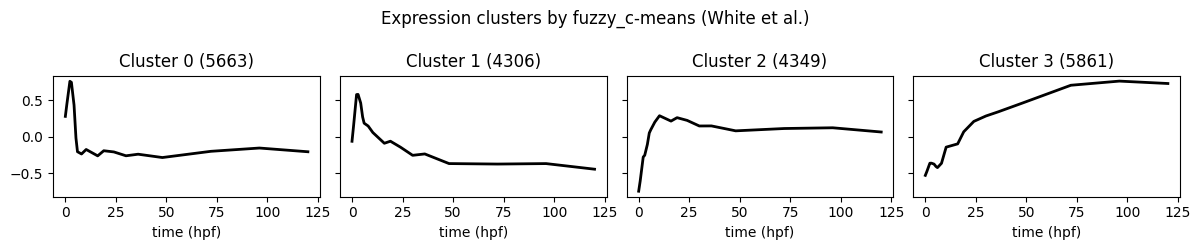

C:\Users\mgrho\AppData\Local\Temp\ipykernel_28936\2669829498.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


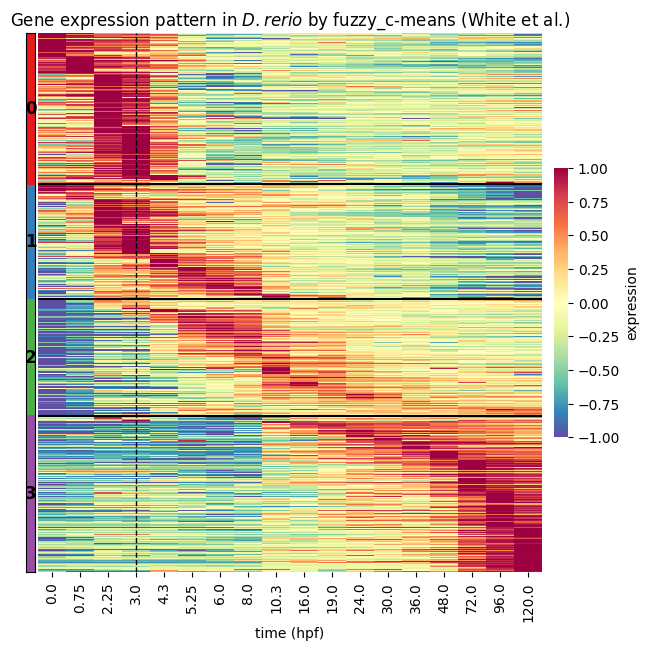

In [19]:
plot_fuzzy_cluster(ds, centers, data_name, algo="fuzzy_c-means")
plot_heatmap(ds, X_z, data_name, algo="fuzzy_c-means")

## TimeSeries KMeans

In [3]:
from tslearn.clustering import TimeSeriesKMeans

def ts_kmeans(ds, data_name,k=5, metric='euclidean'):

    ds["tpm"] = np.log2(ds.tpm+1)
    X = ds["tpm"].transpose("ensembl_gene_id", "time")

    # normalise data
    #X_z = zscore(X.values, axis=1, nan_policy="omit")
    #X_z = (X - X.mean("time")) / X.std("time") # keep xarray shape
    X_z = (X - X.mean("time")) / abs(X - X.mean("time")).max("time")
    #X_z = (X- X.min("time")) /( X.max("time") - X.min("time"))

    # clustering 
    ks = TimeSeriesKMeans(n_clusters=k, random_state=1, metric=metric)  # “euclidean”, “dtw”, “softdtw”
    labels = ks.fit_predict(X_z)

    # Sort clusters by centroid peak time
    peak_times = ks.cluster_centers_[:, :, 0].argmax(axis=1)
    old_order = np.argsort(peak_times)
    label_map = {old: new for new, old in enumerate(old_order)}
    labels = np.array([label_map[l] for l in labels])
    ks.cluster_centers_ = ks.cluster_centers_[old_order]

    # create dataset
    ds = ds.assign_coords(cluster=("ensembl_gene_id", labels))
    ds.to_netcdf(f"results/ts_k-means_{ks.metric}_clustered_ds_{data_name}.nc")
    return ds, ks, X_z

In [ ]:
data_name = "White"
#data_name = "Pauli et al."
#data_name= "BK"
#data_name = "JN"
data = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(source=data_name, drop=True)
# Keep only time steps where tpm has at least one non-NaN value
ds_clean = data.dropna(dim="time", how="all", subset=["tpm"])

# Keep only relevantly expressed genes
mask = ds_clean.tpm.max(dim="time", skipna=True) >= 5
ds_reduced = ds_clean.sel(ensembl_gene_id=mask)

ds, ks, X_z = ts_kmeans(ds_reduced, data_name,k=4, metric="euclidean")
ds

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 20179, time: 18)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 0.0 0.75 2.25 3.0 ... 48.0 72.0 96.0 120.0
    cluster          (ensembl_gene_id) int32 1 3 2 0 0 1 1 2 ... 3 0 0 0 2 3 3 3
Data variables:
    tpm              (time, ensembl_gene_id) float64 1.684 0.3531 ... 3.491
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

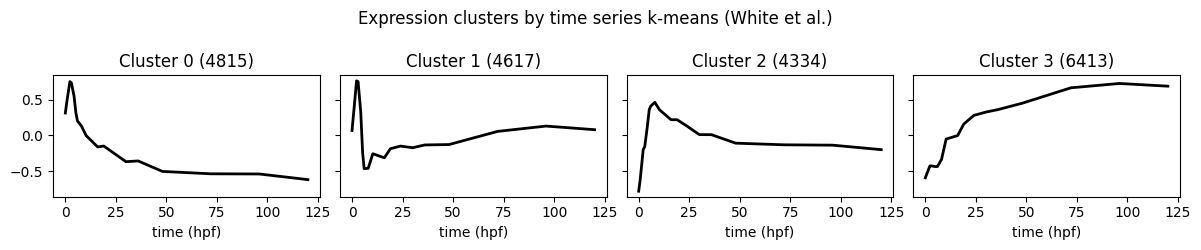

C:\Users\mgrho\AppData\Local\Temp\ipykernel_924\2669829498.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


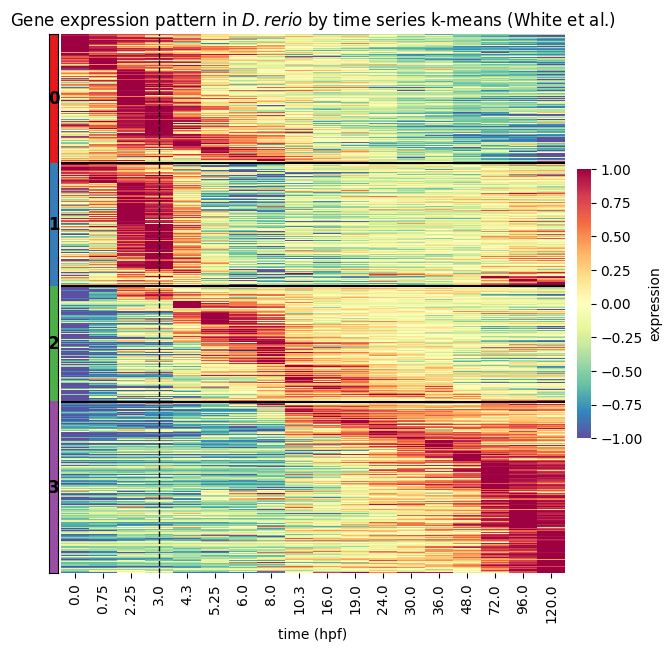

In [5]:
plot_cluster(ds, ks, data_name, algo="time series k-means")
plot_heatmap(ds, X_z, data_name, algo="time series k-means")

## K-Shape clustering

In [94]:
'''k-Shape'''

from tslearn.clustering import KShape
from tslearn.metrics import cdist_normalized_cc

from sklearn.metrics import silhouette_score
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import adjusted_rand_score

def stability_score(data, k, n_runs=10):

    ds = data.dropna(dim="time", how="any")
    max_tpm = ds['tpm'].max(dim='time')
    ds = ds.sel(ensembl_gene_id= (max_tpm>1))
    X = ds["tpm"].transpose("ensembl_gene_id", "time")
    #X = zscore(X.values, axis=1, nan_policy="omit")
    X_z = (X- X.min("time")) /( X.max("time") - X.min("time"))


    labels_list = []

    for i in range(n_runs):
        idx = np.random.choice(len(X), int(0.8*len(X)), replace=False)
        model = KShape(n_clusters=k, random_state=i)
        labels = model.fit_predict(X[idx])
        labels_list.append((idx, labels))

    scores = []
    for i in range(n_runs):
        for j in range(i+1, n_runs):
            idx_i, lab_i = labels_list[i]
            idx_j, lab_j = labels_list[j]

            common = np.intersect1d(idx_i, idx_j)
            if len(common) < 10:
                continue

            map_i = {idx: lab for idx, lab in zip(idx_i, lab_i)}
            map_j = {idx: lab for idx, lab in zip(idx_j, lab_j)}

            li = [map_i[c] for c in common]
            lj = [map_j[c] for c in common]

            scores.append(adjusted_rand_score(li, lj))

    return np.mean(scores)


def silhouette_kshape(data):

    ds = data.dropna(dim="time", how="any")
    max_tpm = ds['tpm'].max(dim='time')
    ds = ds.sel(ensembl_gene_id= (max_tpm>1))
    X = ds["tpm"].transpose("ensembl_gene_id", "time")

    X_z = zscore(X.values, axis=1, nan_policy="omit")
    
    scores = []
    ks = range(2, 15)

    for k in ks:
        D = cdist_normalized_cc(X)  # shape distance matrix
        model = KShape(n_clusters=k, random_state=1)
        labels = model.fit_predict(X_z)
        scores.append(silhouette_score(D, labels, metric="precomputed"))
    
    best_k = ks[np.argmax(scores)]
    print(best_k)

    plt.plot(ks, scores, marker="o")
    plt.xlabel("k")
    plt.ylabel("Silhouette score")
    plt.show()

    return best_k


def k_by_elbow(data):

    # filer dataset
    ds = data.dropna(dim="time", how="any")
    max_tpm = ds['tpm'].max(dim='time')
    ds = ds.sel(ensembl_gene_id= (max_tpm>1))
    X = ds["tpm"].transpose("ensembl_gene_id", "time")

    # normalise data
    X_z = zscore(X.values, axis=1, nan_policy="omit")

    rng = np.random.default_rng(10)
    idx = rng.choice(X.shape[0], size=20000, replace=False)
    X_z = X_z[idx]

    costs = []
    k_values = range(2, 20)

    for k in k_values:
        model = KShape(n_clusters=k, random_state=1)
        model.fit(X_z)
        costs.append(model.inertia_)

    ks = np.array(list(k_values))
    sse_arr = np.array(costs)
    # line between first and last points
    p1 = np.array([ks[0], sse_arr[0]])
    p2 = np.array([ks[-1], sse_arr[-1]])
    # compute distance to line
    distances = []
    for k, s in zip(ks, sse_arr):
        p = np.array([k, s])
        dist = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(dist)
    elbow_k = ks[np.argmax(distances)]
    print("Elbow at k =", elbow_k)

    plt.plot(k_values, costs, marker="o")
    plt.title('Elbow Method')
    plt.grid()
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.show()

    return elbow_k

def k_shape(data, data_name,k=5):

    # filer dataset
    ds = data.dropna(dim="time", how="any")
    max_tpm = ds['tpm'].max(dim='time')
    ds = ds.sel(ensembl_gene_id= (max_tpm>1))
    X = ds["tpm"].transpose("ensembl_gene_id", "time")

    # normalise data
    #X_z = zscore(X.values, axis=1, nan_policy="omit")
    #X_z = (X - X.mean("time")) / X.std("time") # keep xarray shape
    X_z = (X - X.mean("time")) / abs(X - X.mean("time")).max("time")

    # clustering
    ks = KShape(n_clusters=k, random_state=1)
    labels = ks.fit_predict(X_z)

    # Sort clusters by centroid peak time
    peak_times = ks.cluster_centers_[:, :, 0].argmax(axis=1)
    old_order = np.argsort(peak_times)
    label_map = {old: new for new, old in enumerate(old_order)}
    labels = np.array([label_map[l] for l in labels])
    ks.cluster_centers_ = ks.cluster_centers_[old_order]

    # create dataset
    ds = ds.assign_coords(clusters=("ensembl_gene_id", labels))
    ds.to_netcdf(f"clustering/k-shape_clustered_ds_{data_name}.nc")
    return ds, ks, X_z
    

In [ ]:
data_name = "White et al."
#data_name = "Pauli et al."
#data_name= "BK"
#data_name = "JN"
data = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(source=data_name, drop=True)
# Keep only time steps where tpm has at least one non-NaN value
ds_clean = data.dropna(dim="time", how="all", subset=["tpm"])
ds_clean

# Keep only relevantly expressed genes
mask = ds_clean.tpm.max(dim="time", skipna=True) >= 5
ds_reduced = ds_clean.sel(ensembl_gene_id=mask)
ds_reduced

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 20179, time: 18, clusters: 4)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 0.0 0.75 2.25 3.0 ... 48.0 72.0 96.0 120.0
  * clusters         (clusters) int32 0 1 2 3
Data variables:
    tpm              (time, ensembl_gene_id) float64 2.213 0.2773 ... 10.25
    cluster          (ensembl_gene_id) int64 0 3 0 0 0 0 0 2 ... 3 0 0 0 1 3 3 3
    membership       (ensembl_gene_id, clusters) float64 0.831 ... 0.4052
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

In [ ]:
from tslearn.clustering import KShape
from sklearn.metrics import silhouette_score

X = ds["tpm"].transpose("ensembl_gene_id", "time")
X_n = (X - X.mean("time")) / abs(X - X.mean("time")).max("time")
scores = []

k_range = range(2, 16)
for k in k_range:
    model = KShape(n_clusters=k, random_state=0)
    labels = model.fit_predict(X)

    score = silhouette_score(X_n, labels, sample_size=5000)
    scores.append(score)

best_k = k_range[np.argmax(scores)]
print(best_k)
scores

In [ ]:
ds, ks, X_z = k_shape(ds_reduced, data_name, k=best_k)

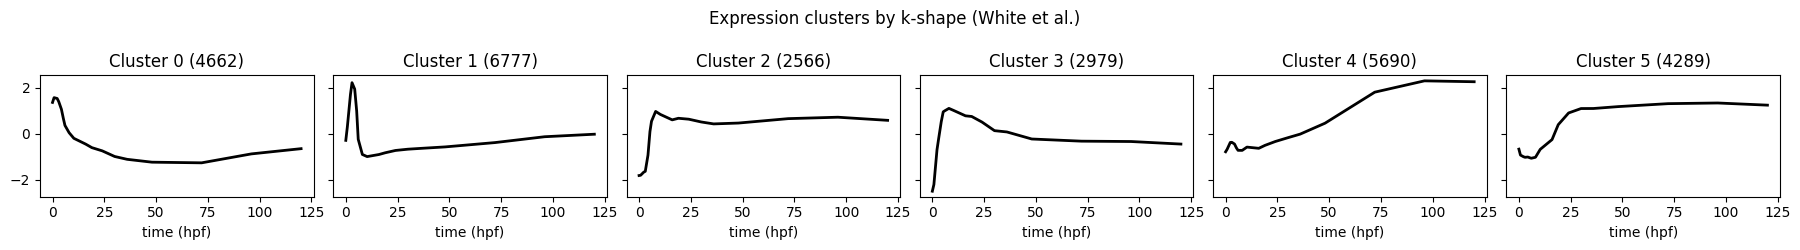

C:\Users\mgrho\AppData\Local\Temp\ipykernel_15204\359752959.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


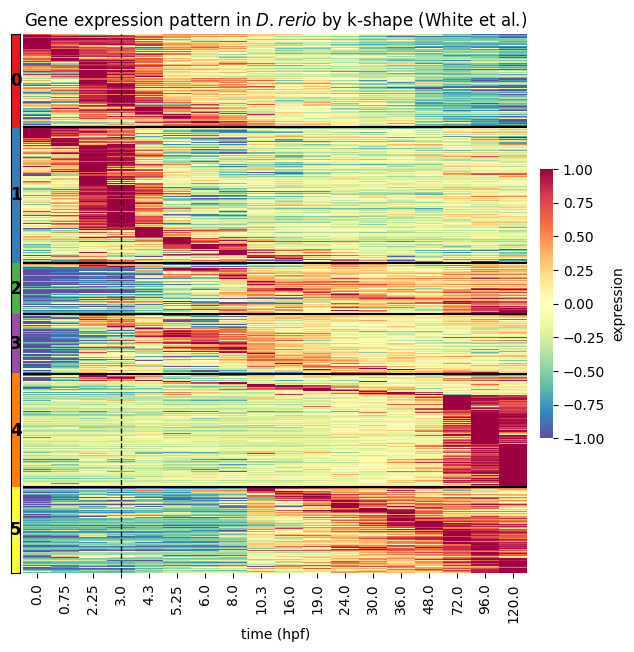

In [9]:
plot_cluster(ds, ks, data_name, algo="k-shape")
plot_heatmap(ds, X_z, data_name, algo="k-shape")

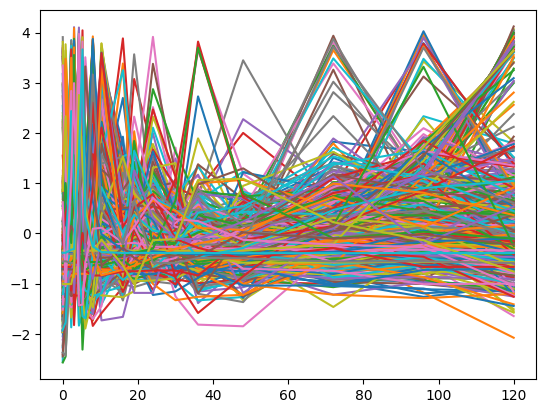

In [6]:
ds1 = (ds.tpm - ds.tpm.mean("time")) / ds.tpm.std("time")

ds_cluster0 = ds1.sel(ensembl_gene_id=ds1.cluster == 2)
genes = ds_cluster0.ensembl_gene_id.values

fig, ax = plt.subplots(1,1)
for g in genes[0:500]:

    ax.plot(ds_cluster0.time, ds_cluster0.sel(ensembl_gene_id=g))

## k-medoids clustering

In [6]:
'''k-medoids'''
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns

def k_by_silhouette(ds):

    rng = np.random.default_rng(42)
    ds["tpm"] = np.log2(ds.tpm+1)
    X = ds["tpm"].transpose("ensembl_gene_id", "time")
    # normalise data
    #X_z = zscore(X.values, axis=1, nan_policy="omit")
    X_z = (X - X.mean("time")) / abs(X - X.mean("time")).max("time")

    k_values = range(2, 20)
    scores = []

    for k in k_values:
        model = KMedoids(n_clusters=k, metric="correlation", random_state=42)
        labels = model.fit_predict(X_z)
        score = silhouette_score(X_z, labels, sample_size=5000,  random_state=42, metric="euclidean")
        scores.append(score)
    best_k = k_values[np.argmax(scores)]
    print(best_k)

    plt.plot(k_values, scores, marker="o")
    plt.xlabel("k")
    plt.ylabel("Silhouette score")
    plt.show()


def k_by_elbow(ds):

    X = ds["tpm"].transpose("ensembl_gene_id", "time")
    # normalise data
    X_z = zscore(X.values, axis=1, nan_policy="omit")
    X_z = (X - X.mean("time")) / abs(X - X.mean("time")).max("time")

    rng = np.random.default_rng(10)
    idx = rng.choice(X.shape[0], size=20000, replace=False)
    X_z = X_z[idx]

    costs = []
    k_values = range(2, 20)

    for k in k_values:
        model = KMedoids(n_clusters=k, random_state=1)
        model.fit(X_z)
        costs.append(model.inertia_)

    ks = np.array(list(k_values))
    sse_arr = np.array(costs)
    # line between first and last points
    p1 = np.array([ks[0], sse_arr[0]])
    p2 = np.array([ks[-1], sse_arr[-1]])
    # compute distance to line
    distances = []
    for k, s in zip(ks, sse_arr):
        p = np.array([k, s])
        dist = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(dist)
    elbow_k = ks[np.argmax(distances)]
    print("Elbow at k =", elbow_k)

    plt.plot(k_values, costs, marker="o")
    plt.title('Elbow Method')
    plt.grid()
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.show()

    return elbow_k

def k_medoids(ds, data_name, k=5):

    ds["tpm"] = np.log2(ds.tpm+1)
    X = ds["tpm"].transpose("ensembl_gene_id", "time")
    # normalise data
   # X_z = zscore(X.values, axis=1, nan_policy="omit")
    X_z = (X - X.mean("time")) / abs(X - X.mean("time")).max("time")

    # clustering
    kmedoids = KMedoids(n_clusters=k, metric="correlation", method="pam", init='k-medoids++', random_state=1)
    labels = kmedoids.fit_predict(X_z)

    # reindex clusters by peak time
    peak_times = np.argmax(kmedoids.cluster_centers_, axis=1)   # peak time index per (old) cluster
    new_order = np.argsort(peak_times)        # old cluster ids, sorted by peak time
    rank = np.argsort(new_order)              # rank[old_id] = new_id

    kmedoids.cluster_centers_ = kmedoids.cluster_centers_[new_order]       # centers reordered
    kmedoids.medoid_indices_ = kmedoids.medoid_indices_[new_order]     # medoids reordered too
    labels_sorted = rank[labels]              # remap hard labels to new ids

    # create dataset
    ds = ds.assign_coords(cluster=("ensembl_gene_id", labels_sorted))
    ds.to_netcdf(f"results/k_medoids_clustered_ds_{data_name}.nc")
    return ds, kmedoids, X_z


In [7]:
data_name = "White et al."
#data_name = "Pauli et al."
#data_name= "BK"
#data_name = "JN"
data = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(source=data_name, drop=True)
# Keep only time steps where tpm has at least one non-NaN value
ds_clean = data.dropna(dim="time", how="all", subset=["tpm"])
ds_clean

# Keep only relevantly expressed genes
mask = ds_clean.tpm.max(dim="time", skipna=True) >= 5
ds_reduced = ds_clean.sel(ensembl_gene_id=mask)
ds_reduced

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 20179, time: 18)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 0.0 0.75 2.25 3.0 ... 48.0 72.0 96.0 120.0
Data variables:
    tpm              (time, ensembl_gene_id) float64 2.213 0.2773 ... 10.25
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

In [8]:
#k = k_by_silhouette(data)
ds, kmedoids, X_z = k_medoids(ds_reduced, data_name, k=4)
ds

c:\Users\mgrho\anaconda3\envs\polya\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 20179, time: 18)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 0.0 0.75 2.25 3.0 ... 48.0 72.0 96.0 120.0
    cluster          (ensembl_gene_id) int64 0 3 1 0 0 0 1 2 ... 3 0 0 0 1 2 3 2
Data variables:
    tpm              (time, ensembl_gene_id) float64 1.684 0.3531 ... 3.491
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

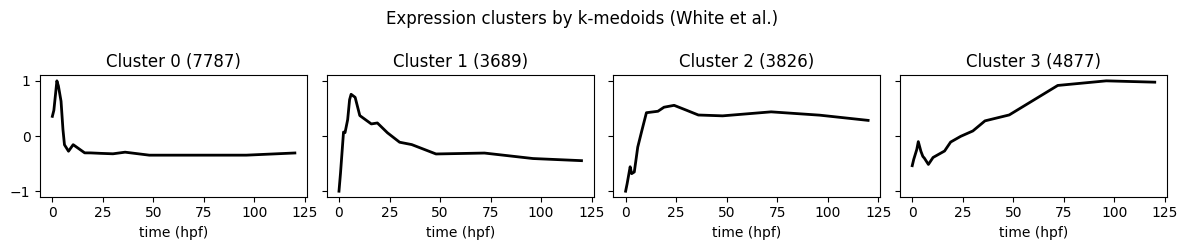

C:\Users\mgrho\AppData\Local\Temp\ipykernel_924\2669829498.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


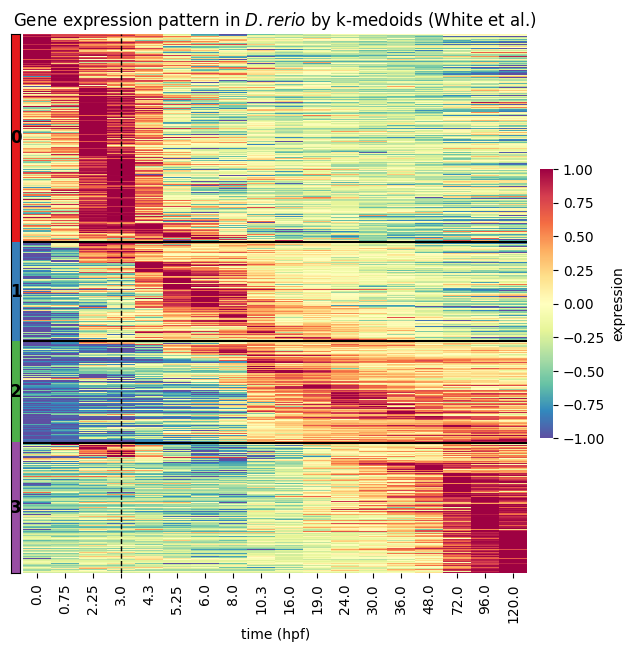

In [9]:
plot_cluster(ds, kmedoids, data_name, algo="k-medoids")
plot_heatmap(ds, X_z, data_name, algo="k-medoids")

## k-means clustering

In [ ]:
'''k-means'''
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns

def k_by_silhouette(data):

    # filer dataset
    ds = data.dropna(dim="time", how="any")
    max_tpm = ds['tpm'].max(dim='time')
    ds = ds.sel(ensembl_gene_id= (max_tpm>1))
    X = ds["tpm"].transpose("ensembl_gene_id", "time")
    # normalise data
    #X_z = zscore(X.values, axis=1, nan_policy="omit")
    X_z = (X - X.mean("time")) / abs(X - X.mean("time")).max("time")

    k_values = range(2, 20)
    scores = []

    for k in k_values:
        model = KMeans(n_clusters=k, random_state=10)
        labels = model.fit_predict(X_z)
        score = silhouette_score(X_z, labels, sample_size=10000,  random_state=10, metric="euclidean")
        scores.append(score)
    best_k = k_values[np.argmax(scores)]
    print(best_k)

    plt.plot(k_values, scores, marker="o")
    plt.xlabel("k")
    plt.ylabel("Silhouette score")
    plt.show()

    return best_k


def k_by_elbow(data):

    # filer dataset
    ds = data.dropna(dim="time", how="any")
    max_tpm = ds['tpm'].max(dim='time')
    ds = ds.sel(ensembl_gene_id= (max_tpm>1))
    X = ds["tpm"].transpose("ensembl_gene_id", "time")

    # normalise data
    X_z = zscore(X.values, axis=1, nan_policy="omit")
    X_z = (X - X.mean("time")) / abs(X - X.mean("time")).max("time")

    rng = np.random.default_rng(10)
    idx = rng.choice(X.shape[0], size=20000, replace=False)
    X_z = X_z[idx]

    costs = []
    k_values = range(2, 20)

    for k in k_values:
        model = KMeans(n_clusters=k, random_state=1)
        model.fit(X_z)
        costs.append(model.inertia_)

    ks = np.array(list(k_values))
    sse_arr = np.array(costs)
    # line between first and last points
    p1 = np.array([ks[0], sse_arr[0]])
    p2 = np.array([ks[-1], sse_arr[-1]])
    # compute distance to line
    distances = []
    for k, s in zip(ks, sse_arr):
        p = np.array([k, s])
        dist = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(dist)
    elbow_k = ks[np.argmax(distances)]
    print("Elbow at k =", elbow_k)

    plt.plot(k_values, costs, marker="o")
    plt.title('Elbow Method')
    plt.grid()
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.show()

    return elbow_k

def k_means(ds, data_name, k=5):

    ds["tpm"] = np.log2(ds.tpm+1)
    X = ds["tpm"].transpose("ensembl_gene_id", "time")

    # normalise data
    #X_z = zscore(X.values, axis=1, nan_policy="omit")
    X_z = (X - X.mean("time")) / abs(X - X.mean("time")).max("time")

    # clustering
    kmeans = KMeans(n_clusters=k,  init='k-means++', random_state=1)
    labels = kmeans.fit_predict(X_z)

    # sort clusters by time of max. expression
    centroid_peak_times = kmeans.cluster_centers_.argmax(axis=1)
    old_order = np.argsort(centroid_peak_times)

    label_map = {old: new for new, old in enumerate(old_order)}
    labels = np.vectorize(label_map.get)(labels)

    kmeans.cluster_centers_ = kmeans.cluster_centers_[old_order]

    # create dataset
    #ds = ds.assign_coords(clusters=("ensembl_gene_id", labels))

    cluster_assigned = xr.DataArray( labels, dims = ("ensembl_gene_id"),
        coords={"ensembl_gene_id": ds.ensembl_gene_id},)
    
    ds["cluster"] = cluster_assigned

    ds.to_netcdf(f"clustering/k-means_clustered_ds_{data_name}.nc")
    return ds, kmeans, X_z

'\ndef plot_heatmap(ds, X_z, data_name):\n\n    from matplotlib.colors import ListedColormap\n\n    # cluster labels\n    clusters = ds[\'cluster\'].values\n    # time axis (index of max expression per gene)\n    time_idx = X_z.argmax(dim="time").values\n\n    # build structured sort: first cluster, then peak time\n    sorted_genes = np.lexsort((time_idx, clusters))\n    expr_plot = X_z.isel(ensembl_gene_id=sorted_genes)\n    sorted_clusters = clusters[sorted_genes]\n\n    # unique clusters in sorted order\n    unique_clusters, start_idx = np.unique(sorted_clusters, return_index=True)\n    end_idx = np.r_[start_idx[1:], len(sorted_clusters)]     # find end indices\n    centers = (start_idx + end_idx) / 2     # compute vertical centers for labels\n\n    cluster_cmap = ListedColormap(sns.color_palette("Set1",))\n\n    fig = plt.figure(figsize=(8,7))\n    gs = fig.add_gridspec(1, 2, width_ratios=[0.015, 1], wspace=0.01)\n\n    # Cluster bar (left)\n    ax_bar = fig.add_subplot(gs[0])\n   

In [ ]:
data_name = "White et al."
#data_name = "Pauli et al."
#data_name= "BK"
#data_name = "JN"
data = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(source=data_name, drop=True)
# Keep only time steps where tpm has at least one non-NaN value
ds_clean = data.dropna(dim="time", how="all", subset=["tpm"])
ds_clean

# Keep only relevantly expressed genes
mask = ds_clean.tpm.max(dim="time", skipna=True) >= 5
ds_reduced = ds_clean.sel(ensembl_gene_id=mask)
ds_reduced

In [ ]:
ds, kmeans, X_z = k_means(ds_reduced, data_name, k=5)

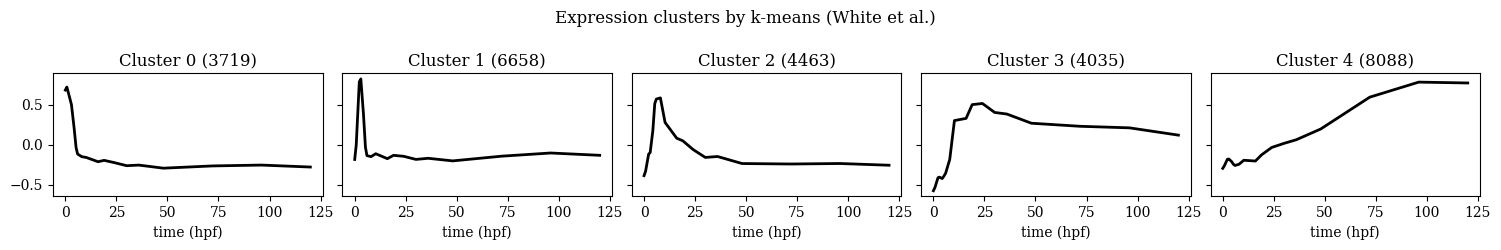

C:\Users\mgrho\AppData\Local\Temp\ipykernel_6132\359752959.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


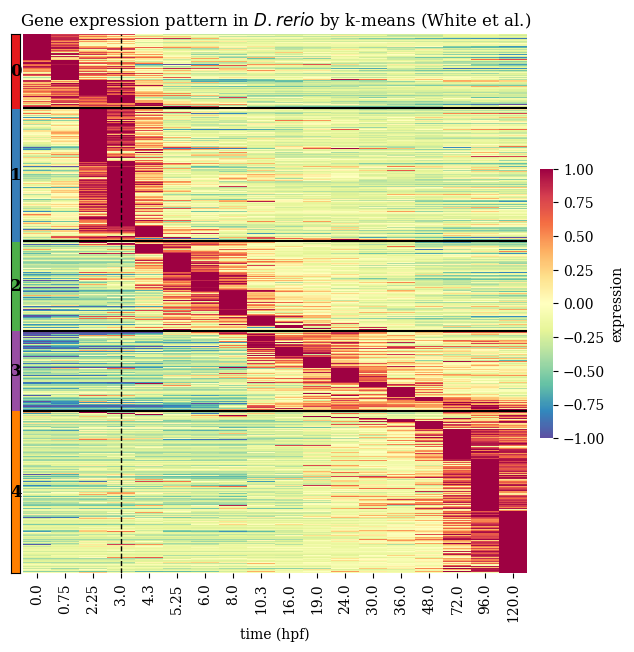

In [182]:
plot_cluster(ds, kmeans, data_name, algo="k-means")
plot_heatmap(ds, X_z, data_name, algo="k-means")

## Compare Results

### Sankey Diagramm

In [159]:
from pySankey.sankey import sankey
import matplotlib.pyplot as plt
import pandas as pd

def cluster_agreement(algo1, algo2):

    ds1 = xr.load_dataset(f"clustering/{algo1}_clustered_ds_White et al..nc")
    ds2 = xr.load_dataset(f"clustering/{algo2}_clustered_ds_White et al..nc")

    df1 = pd.DataFrame({"ensembl_gene_id": ds1.ensembl_gene_id.values, "cluster":ds1.cluster.values})
    df2 = pd.DataFrame({"ensembl_gene_id": ds2.ensembl_gene_id.values, "cluster":ds2.cluster.values})

    df1["cluster2"] = df2["cluster"]
    df1["agreement"] = (df1["cluster"] == df1["cluster2"])
    df = df1.dropna(subset=["cluster", "cluster2"])
    df = df.sort_values(["cluster", "cluster2"], ascending=False)

    left_labels = list(sorted(df["cluster"].dropna().unique()))
    right_labels = list(sorted(df["cluster2"].dropna().unique()))

    sankey(left=df["cluster"], right=df["cluster2"], 
           aspect=20, fontsize=12,
           figure_name=f"clustering/cluster_agreement_{algo1}_algo2")

    # Get current figure
    fig = plt.gcf()
    fig.set_size_inches(6, 6)
    fig.set_facecolor("w")
    plt.title(f"Cluster changes ({algo1} → {algo2})")
    #fig.savefig(f"clustering/cluster_agreement_{algo1}_algo2.png", bbox_inches="tight", dpi=300)

    agree = df["agreement"].sum() / len(df) * 100
    print(f"Cluster agreement: {agree:.2f} %")


Cluster agreement: 34.45 %
Cluster agreement: 48.27 %
Cluster agreement: 43.58 %
Cluster agreement: 15.32 %


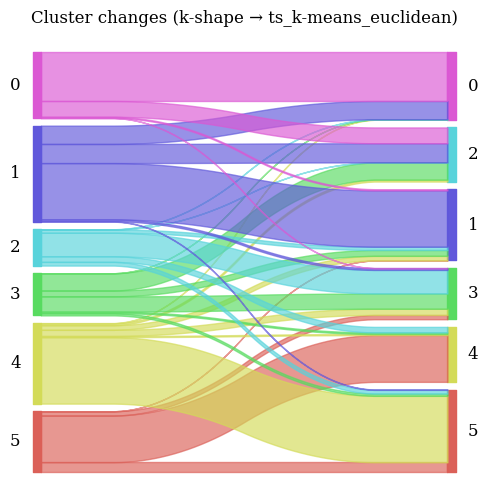

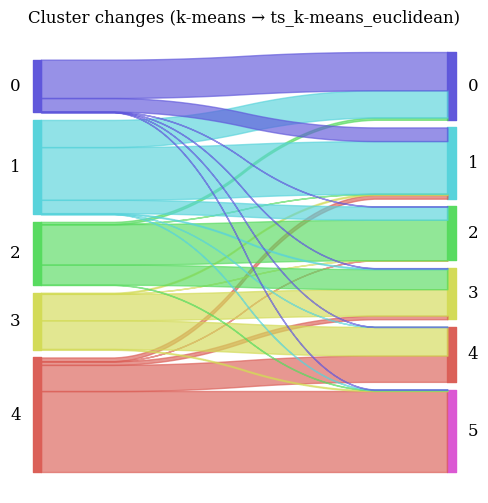

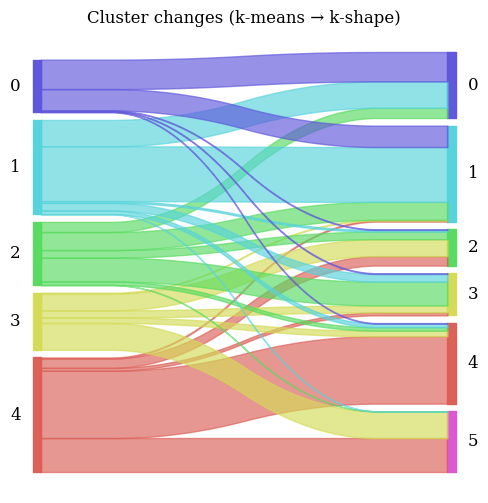

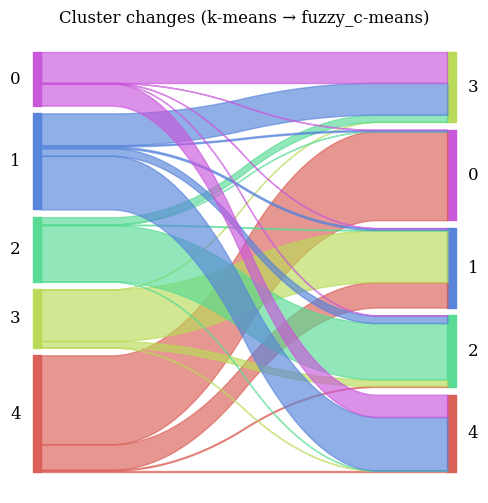

In [183]:
algo1 = "k-shape"
algo2 = "ts_k-means_euclidean"
cluster_agreement(algo1, algo2)

algo1 = "k-means"
algo2 = "ts_k-means_euclidean"
cluster_agreement(algo1, algo2)

algo1 = "k-means"
algo2 = "k-shape"
cluster_agreement(algo1, algo2)

algo1 = "k-means"
algo2 = "fuzzy_c-means"
cluster_agreement(algo1, algo2)

## Tail data

In [66]:
def kmean_clustering_tails(data1, data_name="White", palette="Set1", k_cluster=None):

    import xarray as xr
    import numpy as np
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import zscore
    from sklearn.metrics.pairwise import cosine_distances

    def filter_dataset(ds):
        import xarray as xr
        import pandas as pd
        
        num_positive = (ds['tail_length'] > 0).sum(dim='time_hpf')
        genes_to_keep = (num_positive >= 1)
        ds_filtered = ds.sel(ensembl_gene_id=genes_to_keep)

        return ds_filtered

    ds = filter_dataset(data1).copy()#.sel(time_hpf=slice(0, t_end))

    expr = ds.tail_length

    # Hestilow
    expr_scaled = (expr - expr.mean("time_hpf")) / abs(expr - expr.mean("time_hpf")).max("time_hpf")

    # mix-max normalisation
    #expr_scaled = (expr - expr.min("time_hpf")) / (expr.max("time_hpf") - expr.min("time_hpf"))

    #expr_scaled = expr_scaled.fillna(0)

    X = expr_scaled.transpose('ensembl_gene_id', 'time_hpf').values
    """
    X_centered = X - X.mean(axis=1, keepdims=True)
    norm = np.linalg.norm(X_centered, axis=1, keepdims=True)
    norm[norm == 0] = 1
    X_norm = X_centered / norm
    """
    X_norm = X

    if X_norm.shape[0] == 0:
        raise ValueError(f"No genes passed the filtering step for cluster {k_cluster}")

    print(np.isnan(X_norm).sum())
    
    '''
    --------------------
    Elbow method
    --------------------
    '''
    # from https: //medium.com/ leukemiaairesearch/clustering-techniques-with-gene-expression-data-4b35a04f87d5
    sse = []
    kmeans_kwargs = { "init": "random",  "n_init": 10, "max_iter": 300, "random_state": 1}
    k_range = range(2, 15)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
        #kmeans.fit(expr_scaled)
        kmeans.fit(X_norm)
        sse.append(kmeans.inertia_)

    plt.plot(k_range, sse, 'o-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Sum of squared distances')
    plt.title('Elbow Method')
    plt.grid()
    plt.savefig(f"figs/elbow_method_{data_name}.png")
    plt.close()

    import numpy as np
    ks = np.array(list(k_range))
    sse_arr = np.array(sse)
    # line between first and last points
    p1 = np.array([ks[0], sse_arr[0]])
    p2 = np.array([ks[-1], sse_arr[-1]])
    # compute distance to line
    distances = []
    for k, s in zip(ks, sse_arr):
        p = np.array([k, s])
        dist = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(dist)
    elbow_k = ks[np.argmax(distances)]
    print("Elbow at k =", elbow_k)

    ''' 
    -------------------------------
    k-means clustering
    -------------------------------
    '''

    k = k_cluster if k_cluster else elbow_k
    kmeans = KMeans(init="k-means++", n_clusters=k, random_state=1, n_init=50)
    #labels = kmeans.fit_predict(X)
    labels = kmeans.fit_predict(X_norm)

    # Add cluster labels as a new variable in the Dataset
    ds['cluster'] = (('ensembl_gene_id',), labels)
    cluster_medians = (expr_scaled.groupby(ds.cluster).mean(dim='ensembl_gene_id')    )
    cluster_std = (expr_scaled.groupby(ds.cluster).std(dim='ensembl_gene_id')    )

    # sort cluster centers by time_hpf of maximum expression
    # index of max expression along time_hpf
    peak_time_hpf_idx = cluster_medians.argmax(dim="time_hpf")
    peak_time_hpfs = cluster_medians.time_hpf.values[peak_time_hpf_idx.values]
    new_order = np.argsort(peak_time_hpfs)

    # mapping: old_label -> new_label
    label_map = {old: new for new, old in enumerate(new_order)}
    new_labels = np.array([label_map[c] for c in ds.cluster.values])
    ds['cluster'] = (('ensembl_gene_id',), new_labels)

    cluster_medians = cluster_medians.sel(cluster=new_order)
    cluster_medians = cluster_medians.assign_coords(cluster=np.arange(len(new_order)))
    cluster_std = cluster_std.sel(cluster=new_order)
    cluster_std = cluster_std.assign_coords(cluster=np.arange(len(new_order)))
    ds.to_netcdf(f"data/genes_clustered_{data_name}.nc")

    values = ds.cluster.values
    unique, counts = np.unique(values, return_counts=True)

    cluster_counts = dict(zip(unique, counts))
    print(cluster_counts)


    ''' 
    -------------------------------
    plot profiles - trajectories
    -------------------------------
    '''

    fig, ax = plt.subplots(figsize=(8,5))
    c = sns.color_palette(palette, k)
    for i in range(k):
        #ax.plot(cluster_means['time_hpf'], cluster_means.sel(cluster=i), label=f'Cluster {i}', c=c[i])
        mean = cluster_medians.sel(cluster=i)
        std = cluster_std.sel(cluster=i)
        ax.plot(cluster_medians['time_hpf'], mean, lw=2, label=f'{i}', c=c[i], marker="o", ms=2)
        ax.fill_between(cluster_medians['time_hpf'], y1 = mean-std, y2=mean+std, lw=0.5, color=c[i], alpha=0.1)
    #ax.set(title='Mean gene expression clusters', xlabel='time_hpf (hpf)',ylabel='Expression (log2(TPM + 1))')
    ax.set(title=f'Mean tail dynamics ({data_name})', xlabel='time_hpf (hpf)',ylabel='normalised tail length')
    ax.legend(title="Cluster", loc=(1.01, 0.3), frameon=False)
    #ax.set_xlim(0, 10)
    plt.tight_layout()
    plt.savefig(f"figs/kmeans_expression_cluster_{data_name}.png", dpi=300, transparent=True)
    plt.show()

    #name = ["SD","TU pre-ZGA" ,"TU post-ZGA","SU ZGA" ,"SU post-ZGA"]


    if k == 6:
        fig, ax = plt.subplots(2, 3, figsize=(9, 5), sharey=True, sharex="col")
    else:
        fig, ax = plt.subplots(1, k, figsize=(k*3, 2.5), sharey=True, sharex="col")
    ax = ax.flatten()
    #fig, ax = plt.subplots(k,1, figsize=(4, 12), sharey=True, sharex=True)
    c = sns.color_palette(palette, k)
    for i in range(k):
        #ax.plot(cluster_means['time_hpf'], cluster_means.sel(cluster=i), label=f'Cluster {i}', c=c[i])
        mean = cluster_medians.sel(cluster=i)
        std = cluster_std.sel(cluster=i)
        ax[i].plot(cluster_medians['time_hpf'], mean, lw=2, label=f'{i}', c=c[i], marker="o", ms=2)
        #ax[i].fill_between(cluster_medians['time_hpf'], y1 = mean-std, y2=mean+std, lw=0.5, color=c[i], alpha=0.1)
    #ax.set(title='Mean gene expression clusters', xlabel='time_hpf (hpf)',ylabel='Expression (log2(TPM + 1))')
        ax[i].set_ylabel('tail length')
        ax[i].set_title(f'Cluster {i} ({cluster_counts[i]})', fontsize=12)
        #ax[i].set_title(f'Cluster {i} - {name[i]}', fontsize=16)
    #ax.legend(title="Cluster", loc=(1.01, 0.3), frameon=False)
    #ax.set_xlim(0, 10)
        ax[i].set_xlabel('time (hpf)')
    plt.suptitle(f'Mean tail dynamics clusters ({data_name})', fontsize=16)
    plt.tight_layout()
    plt.savefig(f"figs/kmeans_expression_cluster_{data_name}_subplots.png", dpi=300, transparent=True)
    plt.show()

    ''' 
    -------------------------------
    plot profiles - heatmap
    -------------------------------
    '''
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.colors import ListedColormap

    # cluster labels
    clusters = ds['cluster'].values
    # time axis (index of max expression per gene)
    time_idx = expr_scaled.argmax(dim="time_hpf").values
    #time_idx = expr_scaled.values.argmax(axis=1)
    print(time_idx.shape)
    print(clusters.shape)
    # build structured sort: first cluster, then peak time


    sorted_genes = np.lexsort((time_idx, clusters))
    expr_plot = expr_scaled.isel(ensembl_gene_id=sorted_genes)
    sorted_clusters = clusters[sorted_genes]

    # unique clusters in sorted order
    unique_clusters, start_idx = np.unique(sorted_clusters, return_index=True)
    end_idx = np.r_[start_idx[1:], len(sorted_clusters)]     # find end indices
    centers = (start_idx + end_idx) / 2     # compute vertical centers for labels

    # colormap for clusters
    #k = int(sorted_clusters.max() + 1)
    cluster_cmap = ListedColormap(sns.color_palette(palette,))

    fig = plt.figure(figsize=(8,7))
    gs = fig.add_gridspec(1, 2, width_ratios=[0.015, 1], wspace=0.01)

    # Cluster bar (left)
    ax_bar = fig.add_subplot(gs[0])
    ax_bar.imshow(sorted_clusters[:, None], aspect='auto', cmap=cluster_cmap)
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])
    #ax_bar.set_ylabel("Genes (sorted by cluster)")

    # Add cluster numbers
    for c, y in zip(unique_clusters, centers):
        ax_bar.text(
            0.05, y,
            str(c),
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold',
            color='black',
            transform=ax_bar.transData
        )

    # Heatmap
    ax = fig.add_subplot(gs[1])

    sns.heatmap(
        expr_plot.values,  # .T for white dataset --> changed dimensions in xarray (time, gid) instead of (gid, time)
        cmap='Spectral_r',
        yticklabels=False,
        xticklabels=expr_plot.time_hpf.values,
        ax=ax,
        #cbar_kws={'label': 'Z-score', 'shrink': 0.5, 'pad': 0.02 }
        cbar_kws={'label': 'normalised tail length', 'shrink': 0.5, 'pad': 0.02 }
    )
    
    ax.set_title(f'Poly(A) tail dynamics in $D. rerio$ ({data_name})', fontsize=16)
    ax.set(xlabel='time (hpf)', ylabel='')
    #ax.tick_params("x", rotation=90)

    ax.vlines(3.5, *ax.get_ylim(), colors='k', linewidth=1, ls='--')

    # Find cluster boundaries
    boundaries = np.where(np.diff(sorted_clusters) != 0)[0]
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='k', linewidth=1.5)
    plt.tight_layout()
    plt.savefig(f"figs/heatmap_kmeans_cluster_{data_name}.png", dpi=300, transparent=True)
    plt.show()

    return ds, cluster_medians, X_norm, expr_plot


0
Elbow at k = 6
{0: 708, 1: 942, 2: 2492, 3: 1972, 4: 1234, 5: 1532}


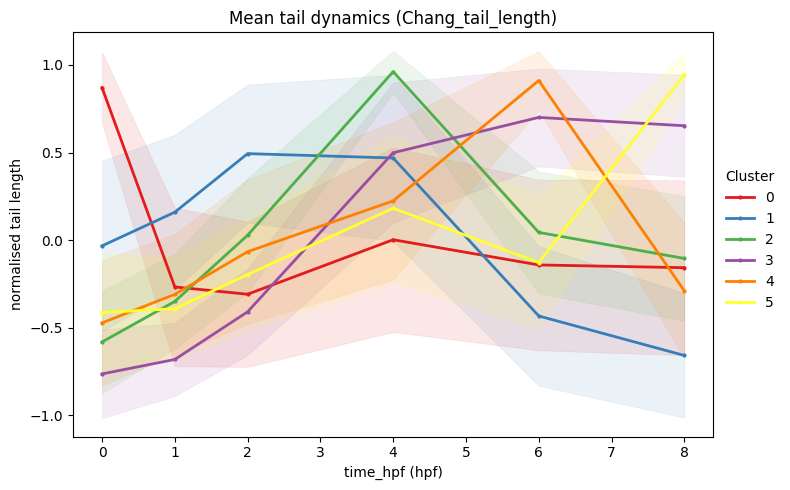

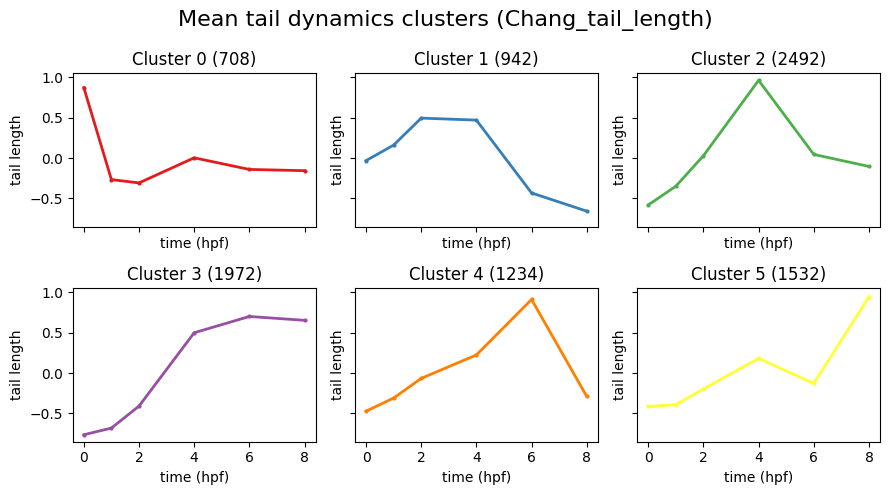

(8880,)
(8880,)


C:\Users\mgrho\AppData\Local\Temp\ipykernel_29384\2453130730.py:255: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


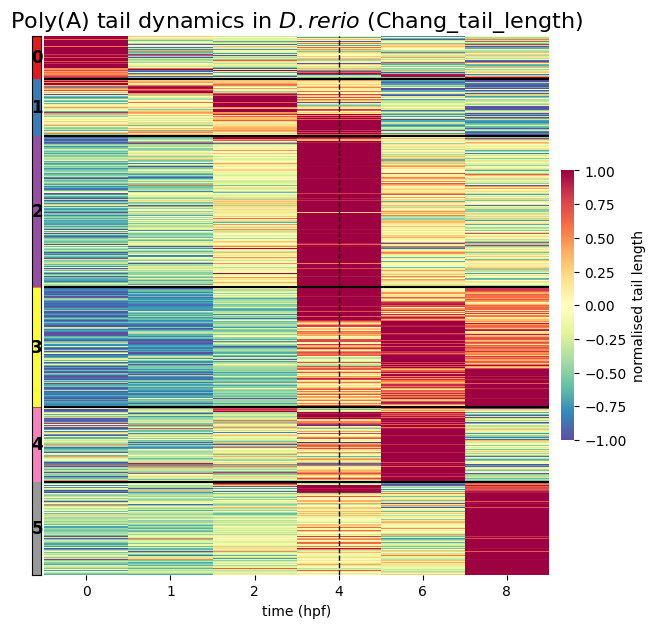

In [67]:
# clustering polyA tail length data

data = xr.load_dataset("data/dataset_Chang_tails_weighted_means.nc")
data_clean = data.dropna(dim="ensembl_gene_id", how="any")

ds, cluster_medians, X_norm, expr_plot = kmean_clustering_tails(data_clean, data_name="Chang_tail_length", palette="Set1", k_cluster=None)

0
Elbow at k = 6
{0: 4121, 1: 1827, 2: 5601, 3: 1149, 4: 2364, 5: 3589}


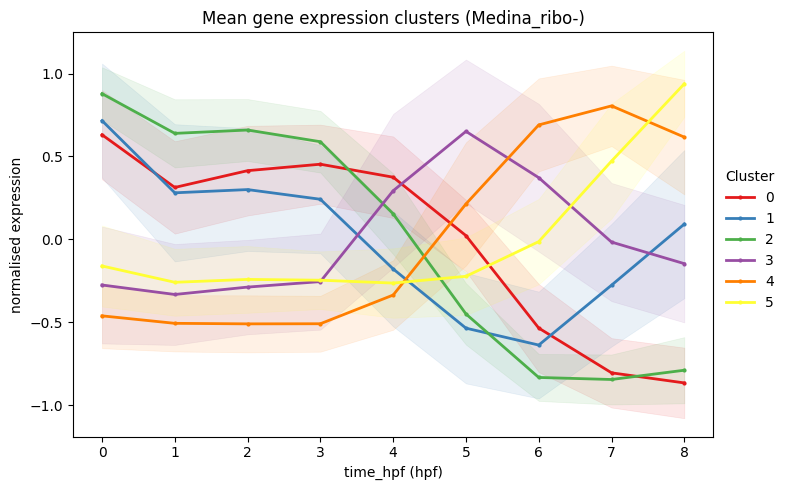

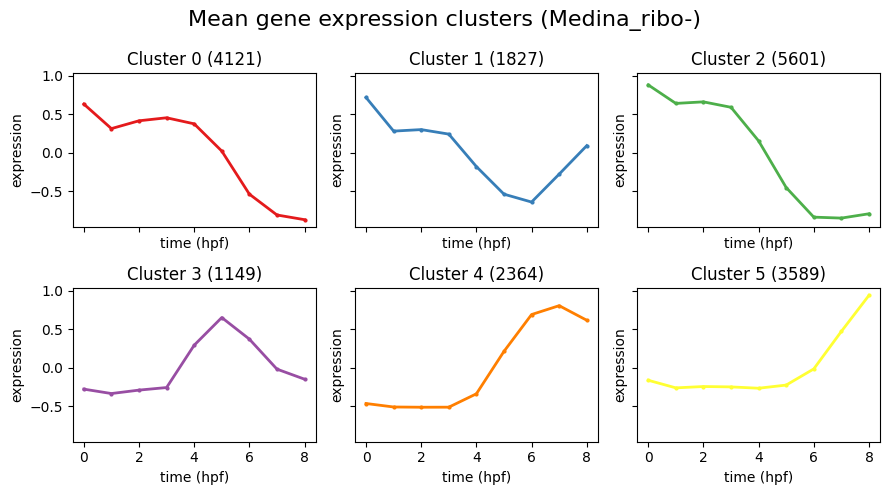

(18651,)
(18651,)


C:\Users\mgrho\AppData\Local\Temp\ipykernel_29384\3277778329.py:256: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


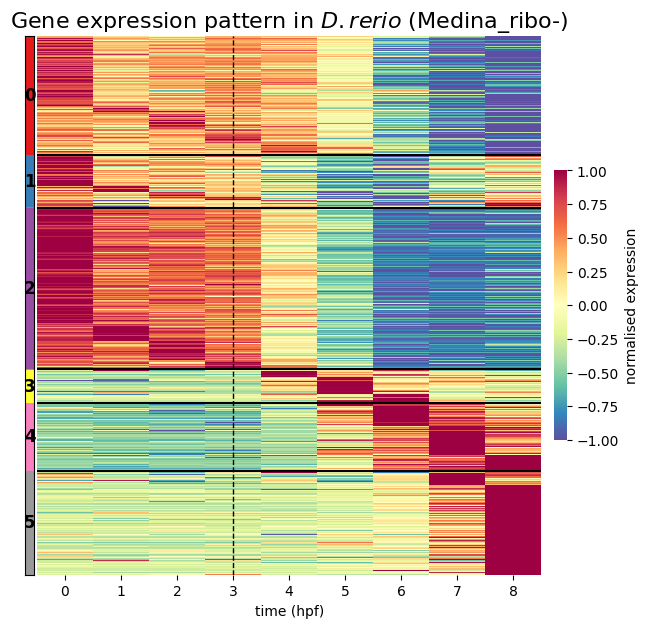

0
Elbow at k = 5
{0: 2736, 1: 5059, 2: 3799, 3: 3689, 4: 4284}


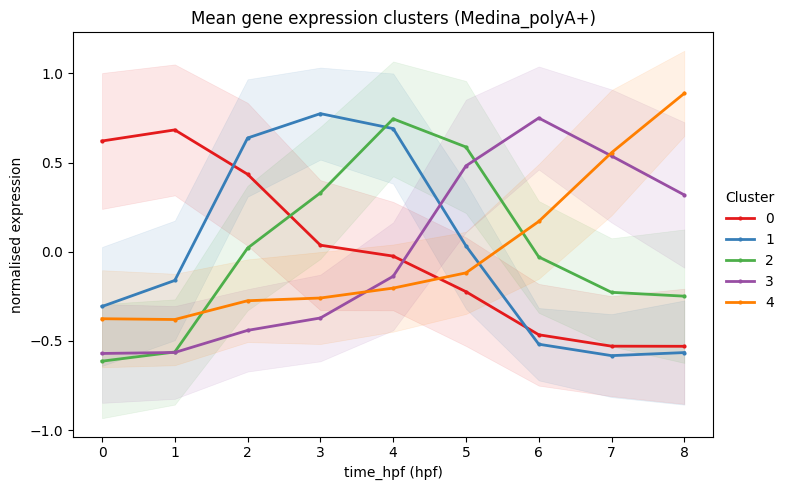

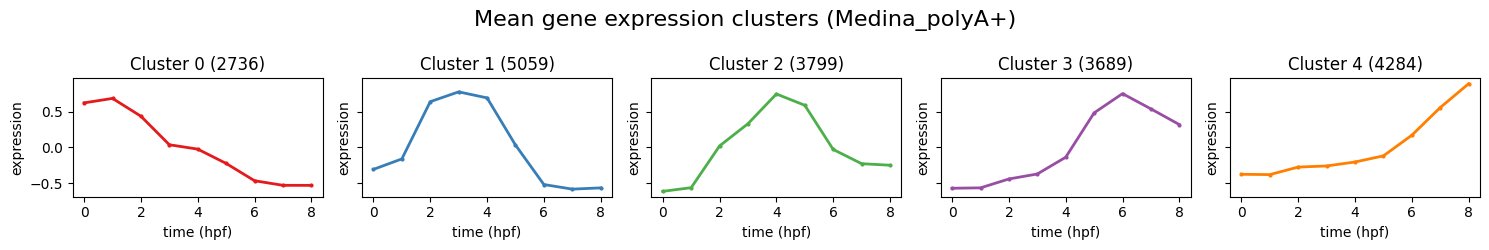

(19567,)
(19567,)


C:\Users\mgrho\AppData\Local\Temp\ipykernel_29384\3277778329.py:256: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


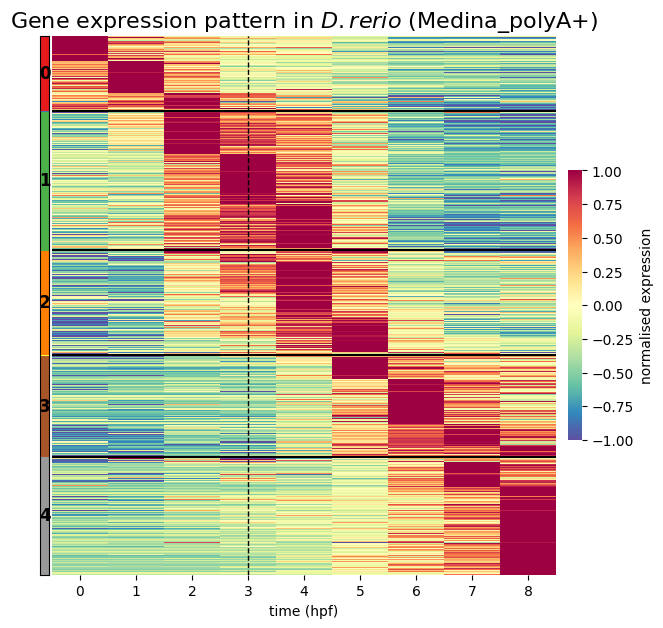

In [70]:
import xarray as xr
data = xr.load_dataset("data/dataset_medina_selection_method.nc").sel(selection_method="ribo-")
ds, cluster_medians, X_norm, expr_plot = kmean_clustering(data,data_name="Medina_ribo-", palette="Set1", k_cluster=None)

data1 = xr.load_dataset("data/dataset_medina_selection_method.nc").sel(selection_method="polyA+")
ds, cluster_medians, X_norm, expr_plot = kmean_clustering(data1,data_name="Medina_polyA+", palette="Set1", k_cluster=None)

In [ ]:
def data_merging(d, ds_cluster, method="ribo-"):

    #d = xr.load_dataset("data/dataset_medina_selection_method.nc").sel(selection_method=method)
    #ds_cluster = xr.load_dataset(f"data/genes_clustered_Medina_{method}.nc")

    df = pd.DataFrame({"ensembl_gene_id": d.ensembl_gene_id.values})
    y = d.tpm

    stats = xr.Dataset(
        {
            "ymin": y.min(dim="time_hpf"),
            "ymax": y.max(dim="time_hpf"),
            "range": y.max(dim="time_hpf") - y.min(dim="time_hpf"),
            "y0": y.isel(time_hpf=0).reset_coords(drop=True),
            "y1": y.isel(time_hpf=1).reset_coords(drop=True), 
            "y120": y.isel(time_hpf=-1).reset_coords(drop=True),
            "t_max": y.idxmax(dim="time_hpf")
        }
    )

    stats_df = stats.to_dataframe().reset_index()

    df = df.merge(stats_df, on="ensembl_gene_id", how="left")

    #df.loc[df["y0"] >= 1, "type"] = "M"
    cond_M = (df["t_max"] <= 3) & (df["y0"] > 1)
    cond_MZ = (df["t_max"] > 3) & (df["y0"] > 1)
    cond_Z = (df["t_max"] > 3) & (df["y0"] <= 1)

    df.loc[cond_M, "type"] = "M"
    df.loc[cond_MZ, "type"] = "MZ"
    df.loc[cond_Z, "type"] = "Z"

    # Build lookup dict once
    cluster_map = dict(
        zip(
            ds_cluster.ensembl_gene_id.values,
            ds_cluster.cluster.values
        )
    )
    # Vectorized map
    df["cluster"] = df["ensembl_gene_id"].map(cluster_map)
    df.to_csv(f"data/datastructure_{method}.csv", index=False)
    return df


C:\Users\mgrho\AppData\Local\Temp\ipykernel_16120\2685097826.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["source"] = df["cluster"]


Text(0.5, 1.0, 'Cluster changes (polyA+ -> ribo-)')

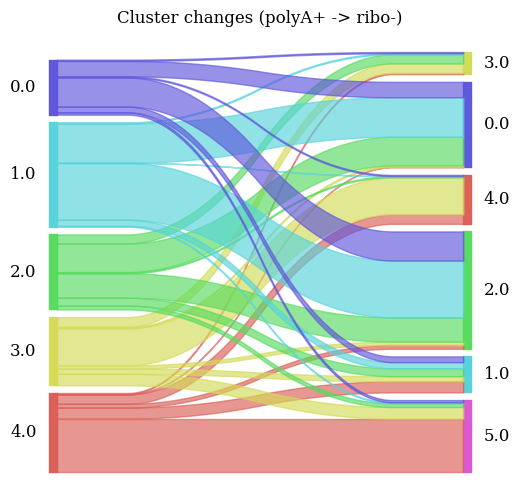

In [ ]:
from pySankey.sankey import sankey
import matplotlib.pyplot as plt
import pandas as pd

d = xr.load_dataset("data/dataset_medina_selection_method.nc")
ds_cluster_ribo = xr.load_dataset(f"data/genes_clustered_Medina_ribo-.nc")
ds_cluster_polya = xr.load_dataset(f"data/genes_clustered_Medina_polyA+.nc")

df_ribo = data_merging(d.sel(selection_method="ribo-"), ds_cluster_ribo, method="ribo-")
df_polya = data_merging(d.sel(selection_method="polyA+"), ds_cluster_polya, method="polyA+")

df_polya["target"] = df_ribo["cluster"]
# drop missing clusters (important for clean Sankey)
df = df_polya.dropna(subset=["cluster", "target"])

# define source → target
df["source"] = df["cluster"] 

df = df.sort_values("source", ascending=False)
# left: polyA+; right: ribo-
sankey(left=df["source"], right=df["target"], aspect=20, fontsize=12)

# Get current figure
fig = plt.gcf()
fig.set_size_inches(6, 6)
fig.set_facecolor("w")
plt.title("Cluster changes (polyA+ -> ribo-)")
#fig.savefig("customers-goods.png", bbox_inches="tight", dpi=150)

### Comparision of White & Medina Dataset

In [117]:
#ds_white = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(source='White et al.').sel(time=slice(0, 8))
ds_medina = xr.load_dataset("data/dataset_medina_selection_method.nc").sel(selection_method="polyA+")

ds_white = xr.load_dataset("C:/Users/mgrho/baseline_gene_expression/data/white_dataset_mean.nc").sel(time=slice(0, 8))

genes = list(set(ds_white.ensembl_gene_id.values) & set(ds_medina.ensembl_gene_id.values))
genes = sorted(genes)
print(f"Number of shared genes: {len(genes)}")

ds_white = ds_white.sel(ensembl_gene_id=(genes))
ds_medina = ds_medina.sel(ensembl_gene_id=(genes))

ds_white = ds_white.rename({"time": "time_hpf", "y": "tpm"})
ds_white["tpm"] = ds_white["tpm"].T
#ds_white = ds_white.where(ds_white["tpm"].notnull(), drop=True)


Number of shared genes: 24170


In [ ]:
from scipy.interpolate import PchipInterpolator
import numpy as np

# interpolate both datasets to common time points and compute NRMSE

df = pd.DataFrame({"gid": genes}, columns=["gid","NRMSE"])
t_common = np.linspace(0, 8, 50)

for g in genes:
    f_m = PchipInterpolator(ds_medina.time_hpf, ds_medina.sel(ensembl_gene_id=g).tpm)
    f_w = PchipInterpolator(ds_white.time_hpf, ds_white.sel(ensembl_gene_id=g).tpm)

    medina = f_m(t_common)
    white = f_w(t_common)

    nrmse = np.sqrt(np.mean((white - medina) ** 2)) / (white.max() + 1e-8 - white.min())
    df.loc[df['gid'] == g, 'NRMSE'] = nrmse

df

df = df[df["NRMSE"] < 2]
df = df.sort_values("NRMSE", ascending=False)
df.NRMSE.hist(bins=50)
plt.title("NRSME distribution (White vs. Medina dataset)")

,gid,NRMSE
0,ENSDARG00000000001,0.192773
1,ENSDARG00000000002,0.396806
2,ENSDARG00000000018,0.193321
3,ENSDARG00000000019,0.344235
4,ENSDARG00000000068,0.436922
...,...,...
24165,ENSDARG00000109022,0.47443
24166,ENSDARG00000109055,0.232208
24167,ENSDARG00000109109,0.654464
24168,ENSDARG00000109164,0.313526


Text(0.5, 1.0, 'Gene ENSDARG00000022767')

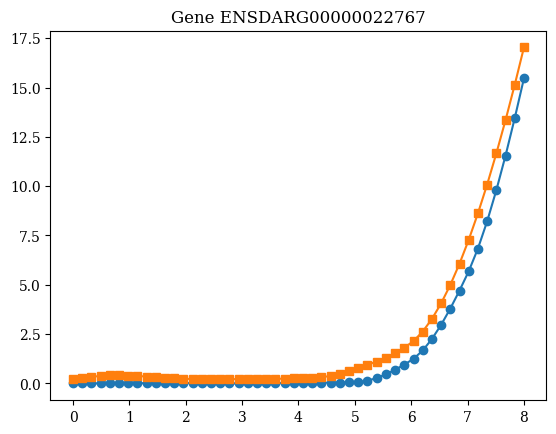

In [ ]:
g = "ENSDARG00000022767"
f_m = PchipInterpolator(ds_medina.time_hpf, ds_medina.sel(ensembl_gene_id=g).tpm)
f_w = PchipInterpolator(ds_white.time_hpf, ds_white.sel(ensembl_gene_id=g).tpm)

medina = f_m(t_common)
white = f_w(t_common)

plt.plot(t_common, medina, "o-", label="Medina polyA+",)
plt.plot(t_common, white, "s-", label="White polyA+")
plt.title(f"Gene {g}")

0
Elbow at k = 5
{0: 2420, 1: 4495, 2: 3314, 3: 2729, 4: 3186}


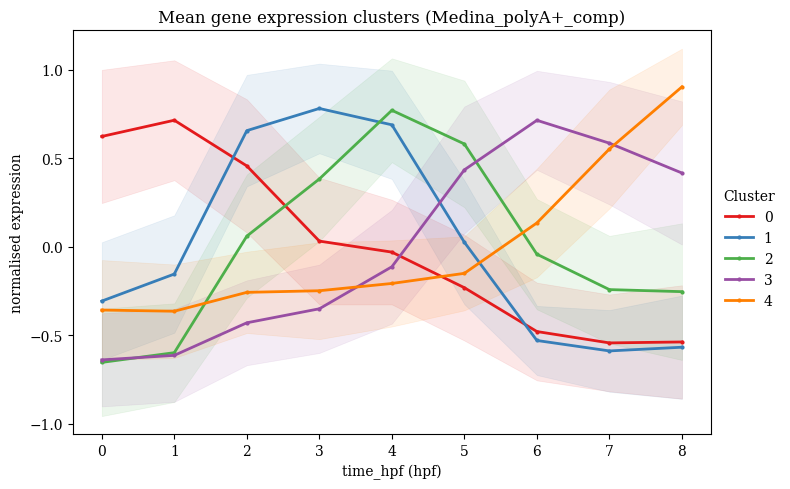

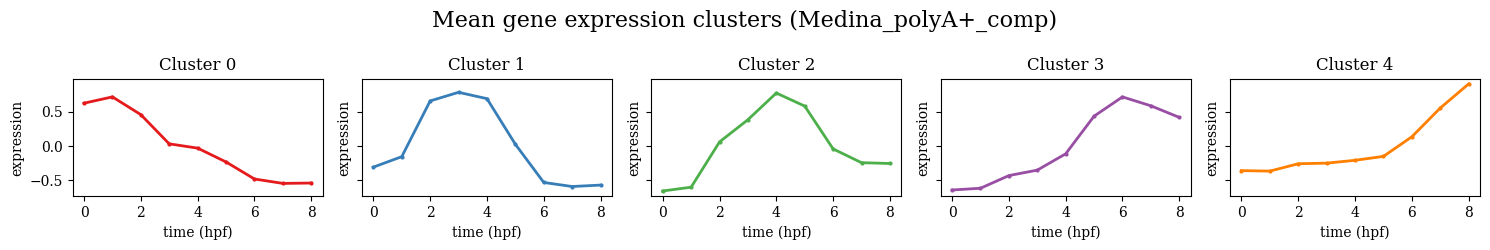

(16144,)
(16144,)


C:\Users\mgrho\AppData\Local\Temp\ipykernel_16120\1568117292.py:257: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


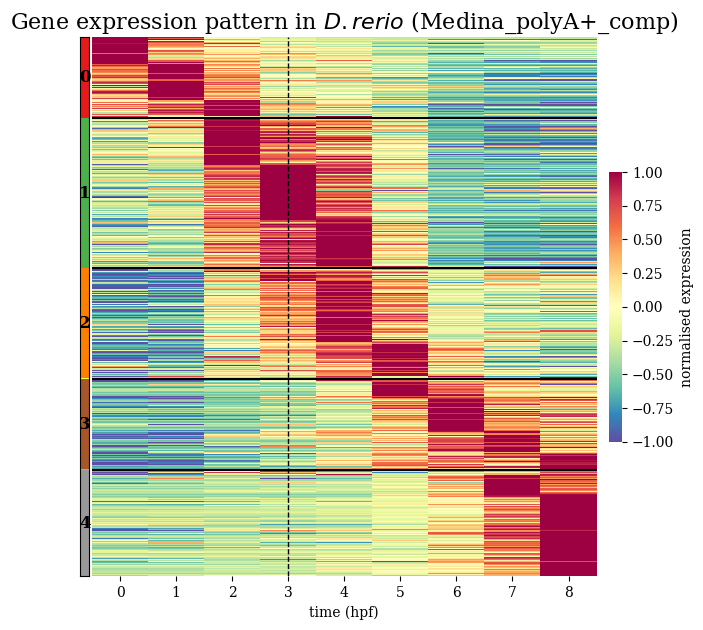

0
Elbow at k = 5
{0: 2948, 1: 4749, 2: 3214, 3: 2613, 4: 2837}


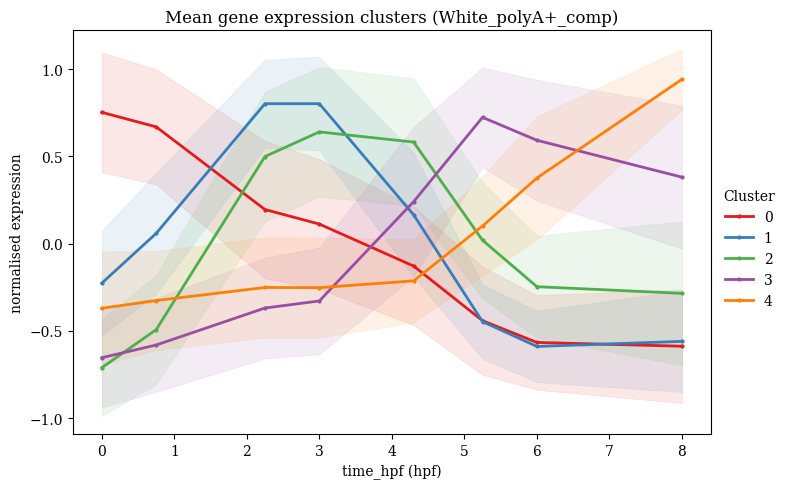

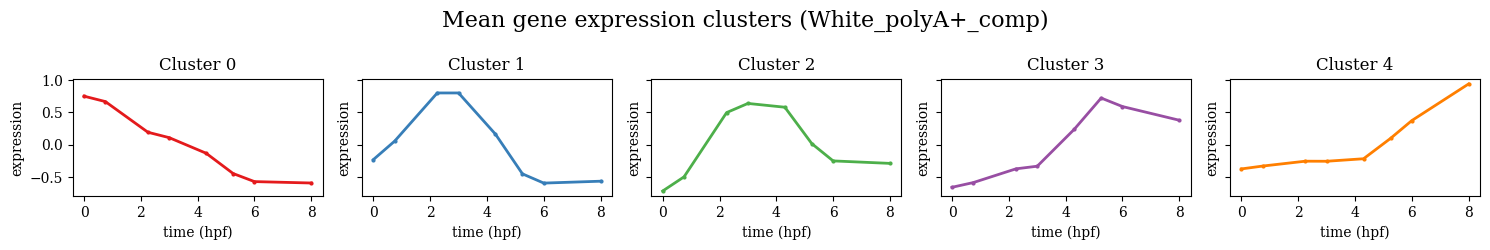

(16361,)
(16361,)


C:\Users\mgrho\AppData\Local\Temp\ipykernel_16120\1568117292.py:257: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


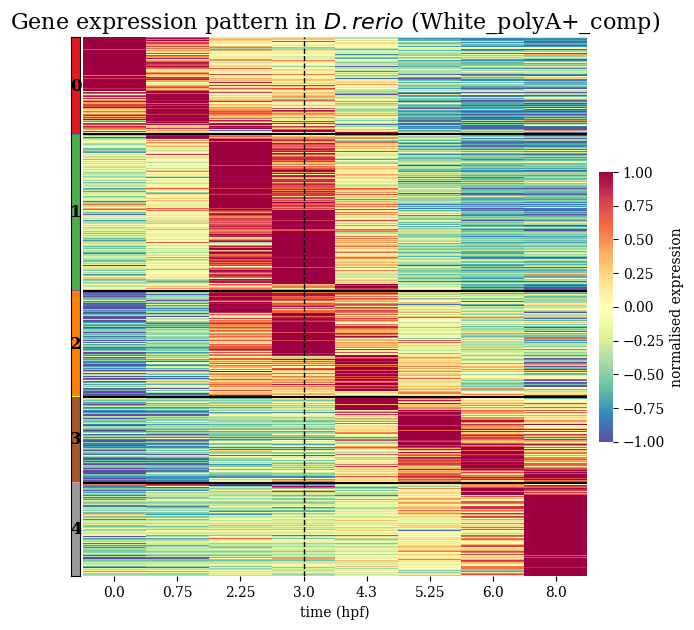

In [120]:
ds, cluster_medians, X_norm, expr_plot = kmean_clustering(ds_medina,data_name="Medina_polyA+_comp", palette="Set1", k_cluster=None)
ds, cluster_medians, X_norm, expr_plot = kmean_clustering(ds_white,data_name="White_polyA+_comp", palette="Set1", k_cluster=None)

In [147]:
df_polya_white.cluster.value_counts()

cluster
1.0    4749
2.0    3214
0.0    2948
4.0    2837
3.0    2613
Name: count, dtype: int64

C:\Users\mgrho\AppData\Local\Temp\ipykernel_16120\866247661.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["source"] = df["cluster"]


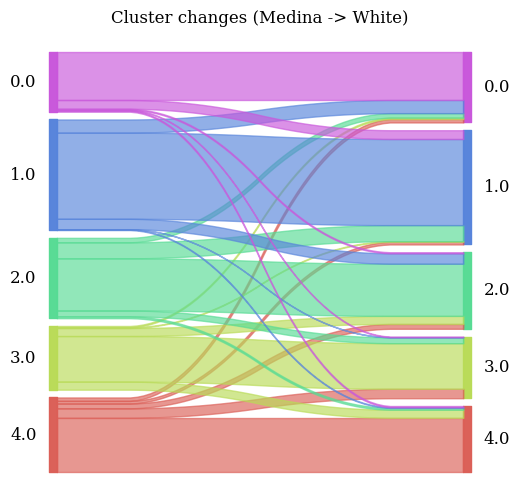

In [149]:
from pySankey.sankey import sankey
import matplotlib.pyplot as plt
import pandas as pd


ds_cluster_medina = xr.load_dataset(f"data/genes_clustered_Medina_polyA+_comp.nc")
ds_cluster_white = xr.load_dataset(f"data/genes_clustered_White_polyA+_comp.nc")

df_polya_medina = data_merging(ds_medina, ds_cluster_medina, method="polyA+")
df_polya_white = data_merging(ds_white, ds_cluster_white, method="polyA+")

df_polya_medina["target"] = df_polya_white["cluster"]
# drop missing clusters (important for clean Sankey)
df = df_polya_medina.dropna(subset=["cluster", "target"])

# define source → target
df["source"] = df["cluster"] 

df = df.sort_values(["source", "target"], ascending=False)
# left: polyA+; right: ribo-
sankey(left=df["source"], right=df["target"], aspect=20, fontsize=12)

# Get current figure
fig = plt.gcf()
fig.set_size_inches(6, 6)
fig.set_facecolor("w")
plt.title("Cluster changes (Medina -> White)")
fig.savefig("figs/cluster_changes.png", bbox_inches="tight", dpi=150)

In [ ]:
ds, cluster_medians, X_norm, expr_plot = leiden_clustering(ds_medina,data_name="Medina_polyA+_comp", palette="Set1",)
ds, cluster_medians, X_norm, expr_plot = leiden_clustering(ds_white,data_name="White_polyA+_comp", palette="Set1", )

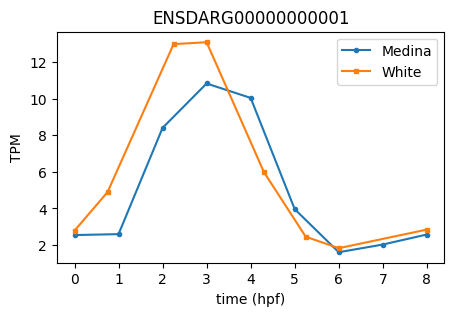

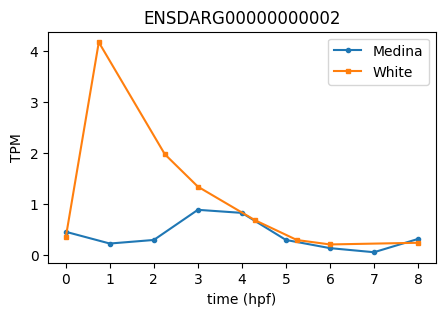

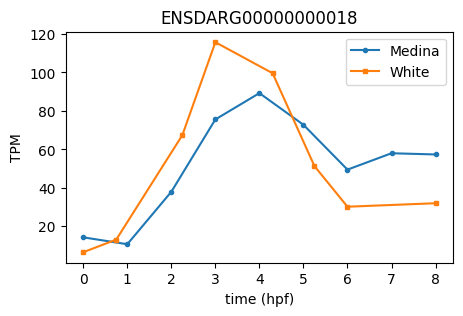

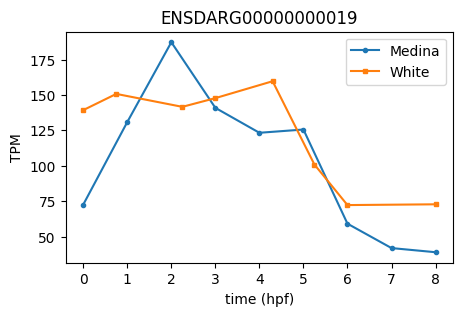

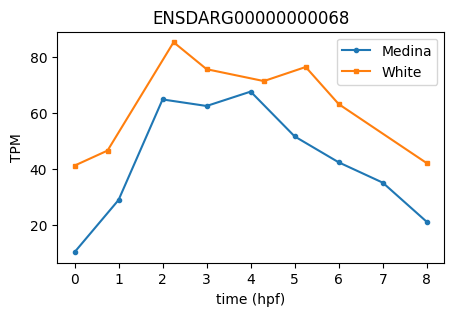

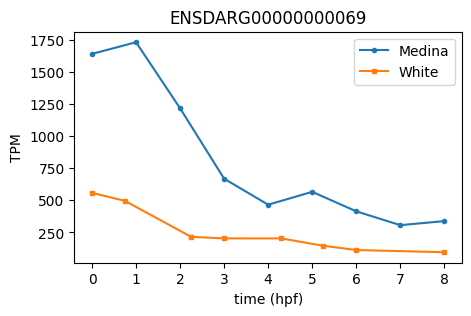

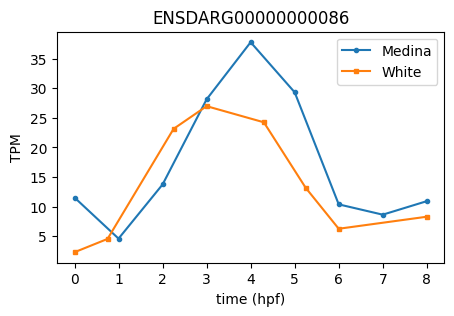

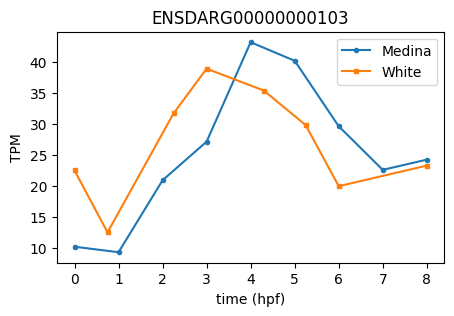

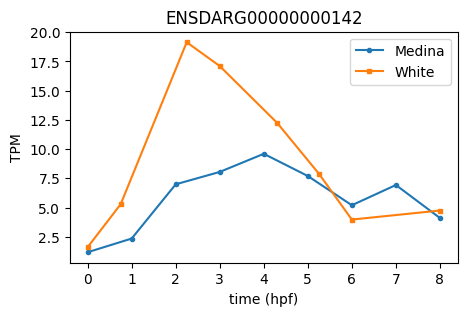

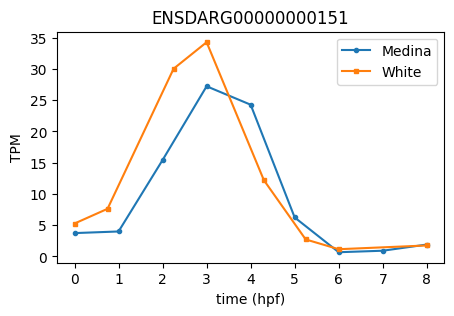

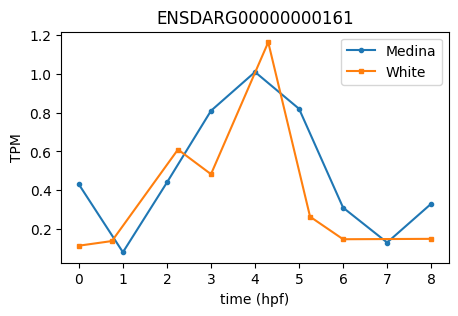

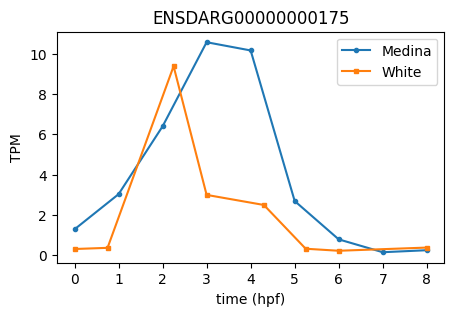

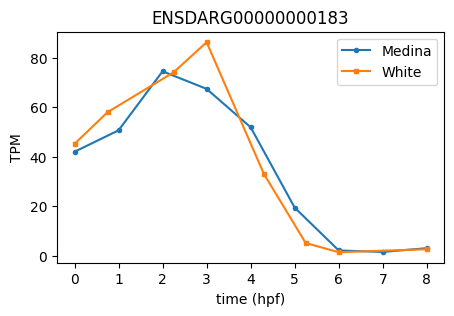

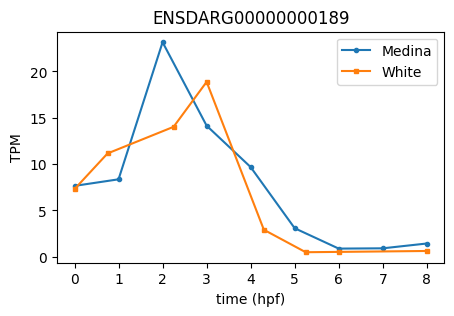

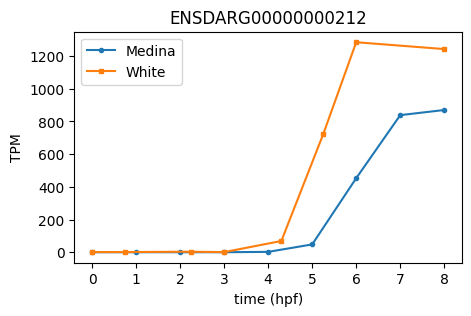

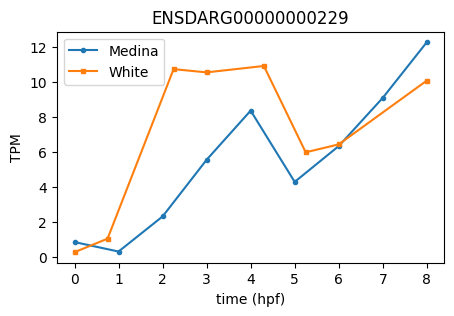

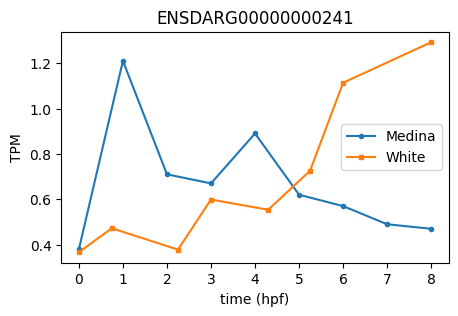

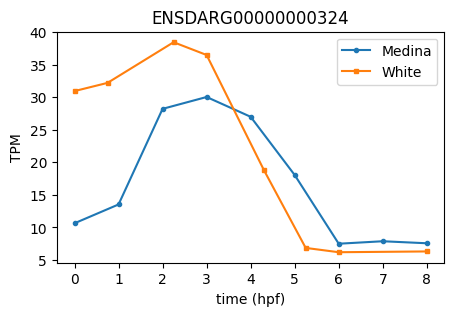

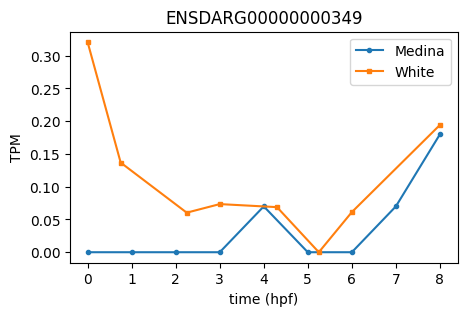

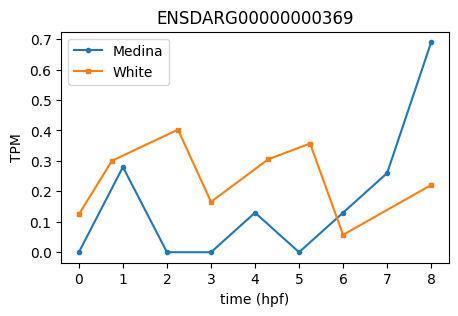

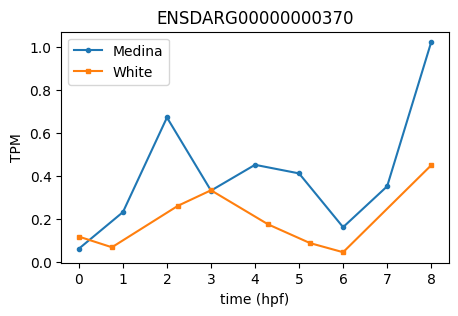

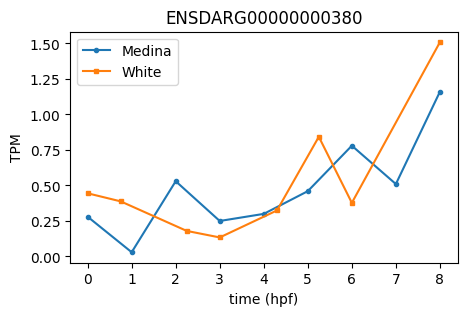

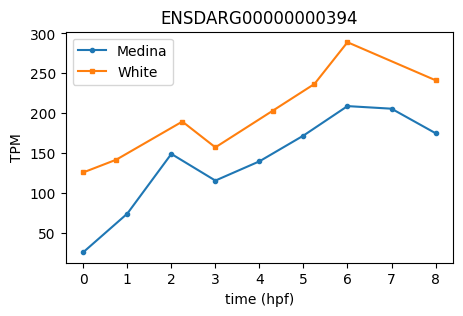

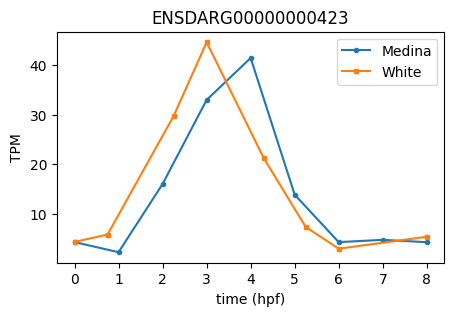

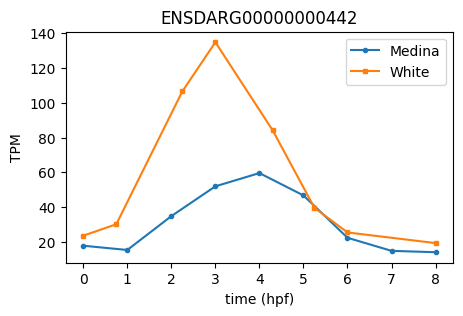

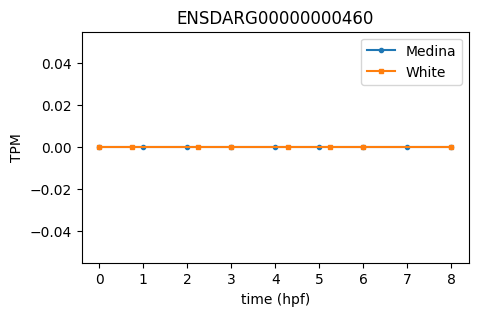

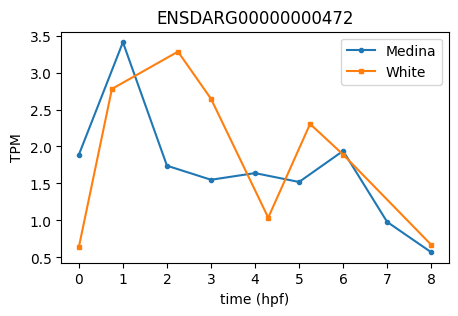

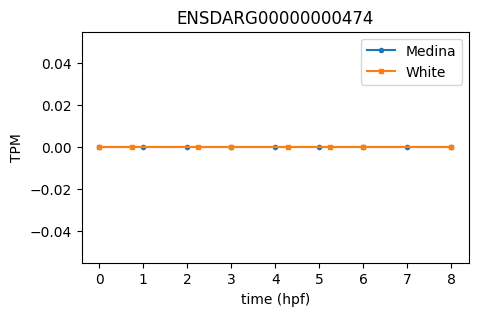

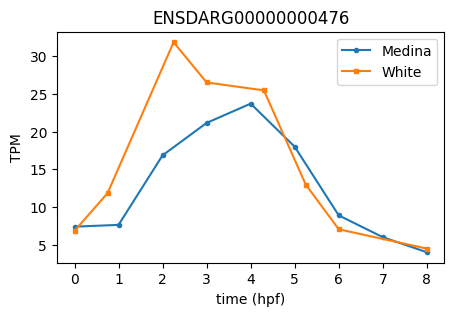

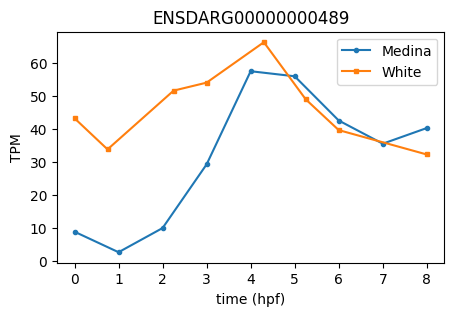

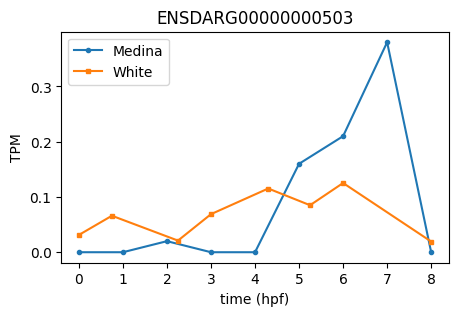

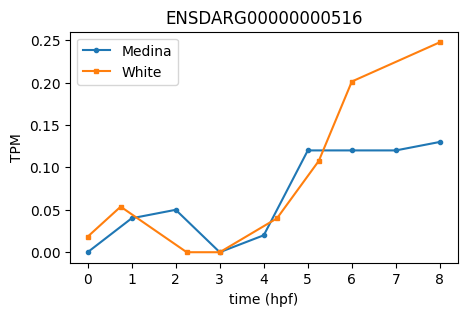

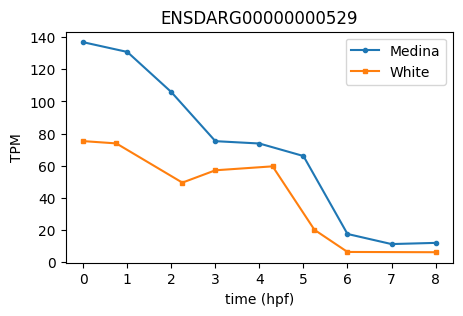

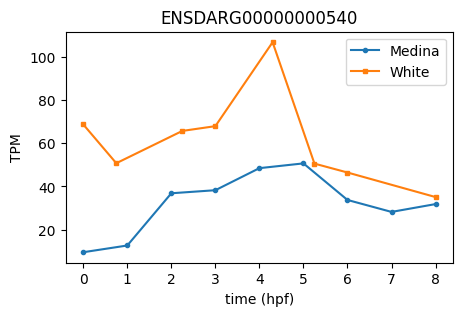

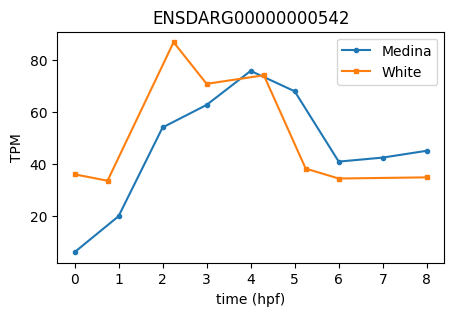

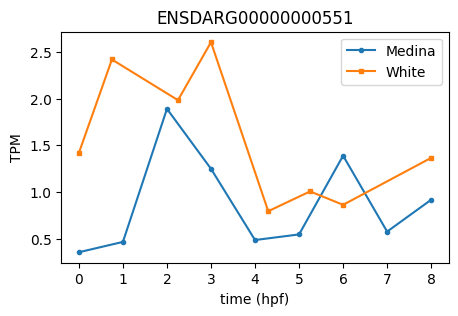

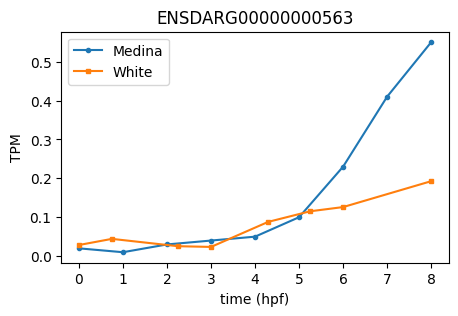

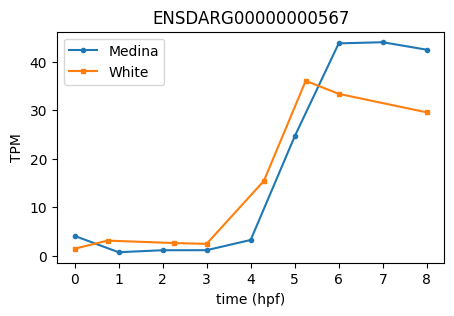

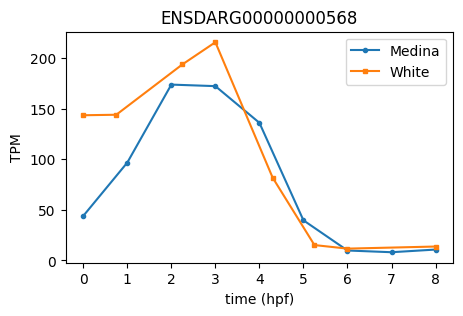

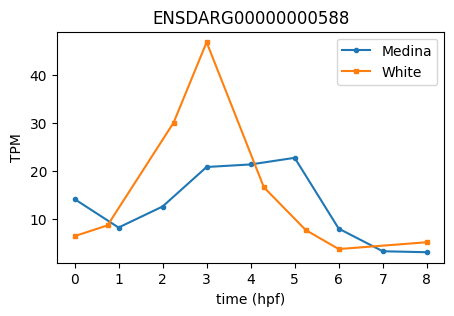

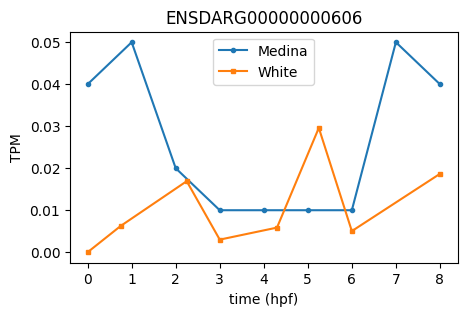

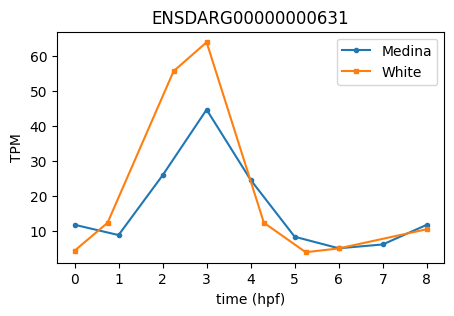

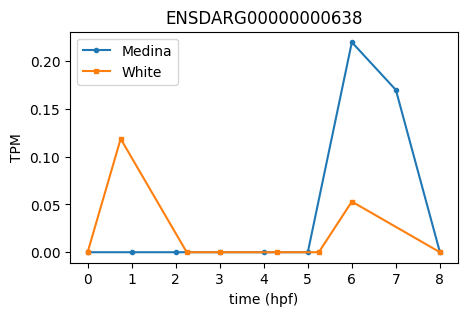

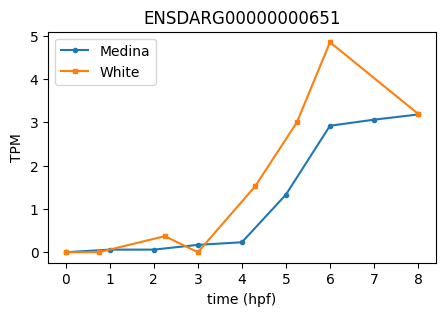

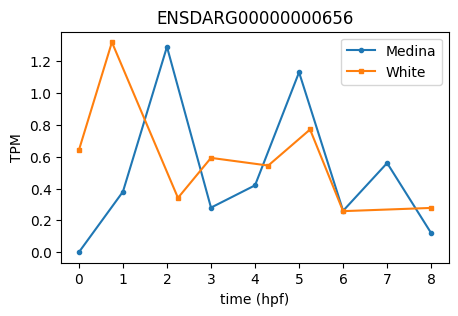

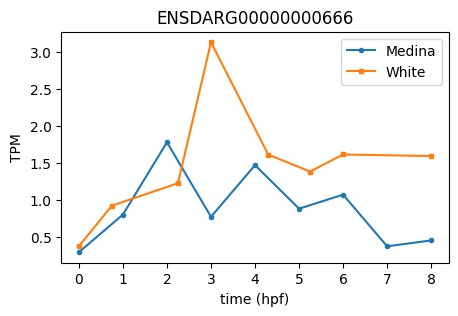

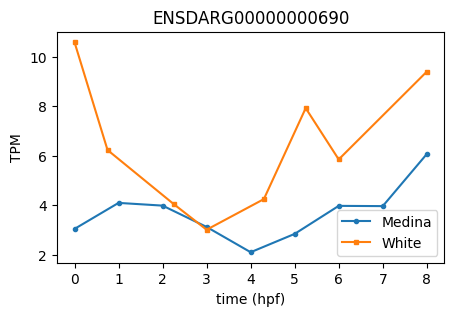

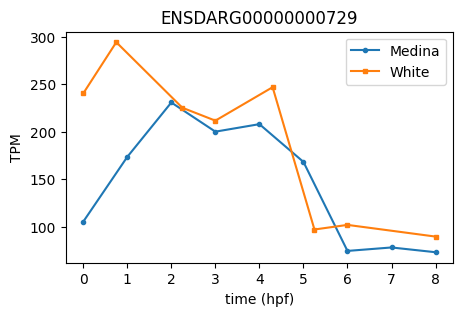

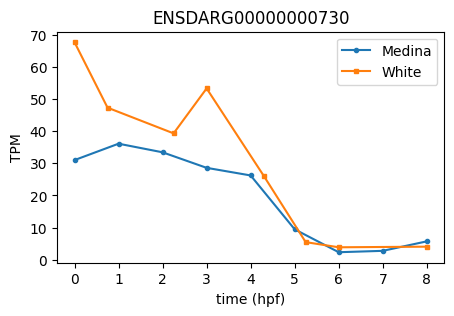

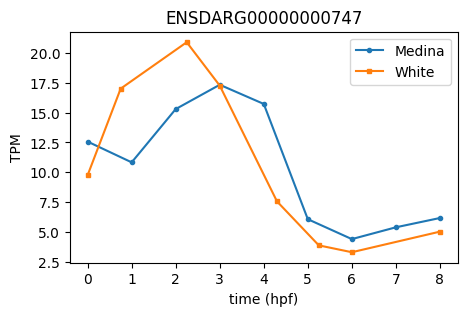

In [13]:
genes.sort()
for g in genes[0:50]:
    fig, ax = plt.subplots(figsize=(5,3))
    plt.plot(ds_medina.time_hpf, ds_medina.tpm.sel(ensembl_gene_id=g), label="Medina", marker="o", markersize=3)
    plt.plot(ds_white.time_hpf, ds_white.tpm.sel(ensembl_gene_id=g), label="White", marker="s", markersize=3)
    plt.title(g)
    plt.xlabel("time (hpf)")
    plt.ylabel("TPM")
    plt.legend()
    plt.show()